In [1]:
import os 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import copy
import math
import time
import shutil
import bisect
import threading
import matplotlib.patches as patches
from matplotlib.collections import LineCollection
from matplotlib.colors import hsv_to_rgb
from scipy.signal import savgol_filter
from scipy.stats import median_abs_deviation

import tkinter as tk
from tkinter import filedialog
from math import*
from ParseEvent import ParseEvent


def Distance(pos1:list, pos2:list) -> float:
    return sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

root = tk.Tk()
root.withdraw()

mouseNames:list[str] = []
LogsFolders:list[str] = []
configs = []

All_folder_paths = "tempSummaryLogs"
if All_folder_paths == "":
    All_folder_paths = filedialog.askdirectory(initialdir = os.getcwd(), title="选择包含指定批次Log数据的文件夹")
if not All_folder_paths:
    exit()

# 遍历每个选择的文件夹
for folder_path in os.listdir(All_folder_paths):
    if not folder_path.startswith("#") and os.path.isdir(os.path.join(All_folder_paths, folder_path)):
        mouseNames.append(folder_path)
        LogsFolders.append(os.path.join(All_folder_paths, folder_path))
    elif os.path.isfile(os.path.join(All_folder_paths, folder_path)):
        mouseNames.append(All_folder_paths)
        LogsFolders.append(All_folder_paths)
        break


recfileList = []
recfileListTimeList = []
posfileList = []
logeventList = []
logeventRenamedList = []
logeventTimeList = []


limitedColumns = ['type', 'delta time', 'mode', 'trial', 'lickPos', 'result']
for mouseIndex in LogsFolders:
    recfileList.append([])
    posfileList.append([])
    logeventList.append([])
    logeventRenamedList.append([])
    recfileListTimeList.append([])
    logeventTimeList.append([])

    for file in os.listdir(mouseIndex):
        if file.endswith("rec.txt"):    
            recfileList[-1].append(file)
            recfileListTimeList[-1].append(time.strftime("%m_%d", time.localtime(os.path.getmtime(os.path.join(mouseIndex, file)))))
        elif file.endswith("pos.txt"):
            posfileList[-1].append(file)
        elif file.endswith(".evt"):
            if "_evt" not in file:
                logeventList[-1].append(mouseIndex + "/" + file)
                logeventRenamedList[-1].append("")

            else:
                logeventList[-1].append("")
                logeventRenamedList[-1].append(mouseIndex + "/" + file)
            logeventTimeList[-1].append(time.strftime("%m_%d", time.localtime(os.path.getmtime(os.path.join(mouseIndex, file)))))
    recfileList[-1].sort()
    posfileList[-1].sort()

def readToDataRows(_fname, _dataRows, _addtion:list = None):
    _config = ""
    with open(_fname, 'r') as file:
        for line in file:
            line.strip()
            if IsValidDataLine(line):
                # 按制表符分割行，并添加到数据行列表中
                _dataRows.append(line.strip().split('\t')[0:len(limitedColumns)])
                #if len(dataRows) > 1:
                    #dataRows[-1][1] = float(dataRows[-1][1])
                #dataRowsTyped.append(dataRows[-1])
            elif line.startswith("{"):
                _config += line + "\n"
            if _addtion is not None:
                if "Trial initialized" in line:
                    _addtion.clear()
                if "started at " in line:
                    _addtion.append(line[line.index("started at "):line.index("started at ") + 1])

    return _config

AllMouseRecMainDfs = []
AllMousePosMainDfs = []
AllMouseEventLs = []
AllMouseAddLs = []
sceneinfo = None
selectedArea = '''34	0	378	478	120	1
33	0	477	745	120	1
32	0	736	864	120	1
36	0	764	120	120	1
35	0	497	219	120	1
37	0	1023	239	120	1
39	0	1003	765	120	1
38	0	1122	506	120	1'''
selectedArea = selectedArea.strip().split('\n')


def IsValidPosLine(tempDfValue:pd.Series) -> bool:
    if len(tempDfValue) == 6:
        try:
            _y = int(tempDfValue['y'])
            int(tempDfValue['frameInd'])
            _t = float(tempDfValue['TimeInUnitySecFromTrialStart'])
        
            if _y in [0, 1] and int(_t) in [0, 1]:
                return False
            else:
                return True
        except:
            return False
    return False

def IsValidDataLine(line:str) -> bool:
    splited = line.split('\t')
    if len(splited) == 6:
        try:
            float(splited[1])
            int(splited[3])
            return True
        except:
            return False
    return False

for mouseIndex in range(0, len(recfileList)):#fileList按mouse排序
    AllMouseRecMainDfs.append([])
    AllMousePosMainDfs.append([])
    AllMouseEventLs.append([])
    AllMouseAddLs.append([])
    configs.append([])
    for i, DailyRecord in enumerate(recfileList[mouseIndex]):
        _datarows = []
        _config = readToDataRows(LogsFolders[mouseIndex] + "/" + DailyRecord, _datarows, AllMouseAddLs[mouseIndex])
        configs[-1].append(_config)

        nowDf = pd.DataFrame(_datarows, columns=limitedColumns)
        nowDf = nowDf.drop(nowDf.index[nowDf['type'] == "type"])
        nowDf['delta time'] = np.float64(nowDf['delta time'])

        AllMouseRecMainDfs[-1].append(nowDf)
        recfileName = recfileList[mouseIndex][i].split("_rec")[0]
        evtfilename = LogsFolders[mouseIndex] + "/" + recfileName + "_evt.evt"
        if evtfilename in logeventRenamedList[mouseIndex]:
            AllMouseEventLs[-1].append(evtfilename)
        else:
            date = recfileListTimeList[mouseIndex][i]
            if date in logeventTimeList[mouseIndex]:
                index = logeventTimeList[mouseIndex].index(date)
                AllMouseEventLs[-1].append(logeventList[mouseIndex][index])
                if logeventList[mouseIndex][index].split("/")[-1].split("_evt.evt")[0] != DailyRecord.split('_rec')[0]:
                    new_evt_name = "/".join(logeventList[mouseIndex][index].split("/")[:-1]) + "/" + DailyRecord.split('_rec')[0] + "_evt.evt"
                    shutil.copy2(logeventList[mouseIndex][index], new_evt_name)
            else:
                AllMouseEventLs[-1].append("")
            
    for DailyPos in posfileList[mouseIndex]:
        _datarows = []
        
        nowDf = pd.read_csv(LogsFolders[mouseIndex] + "/" + DailyPos,sep='\t',names=['x','y', 'syncInd', "100*pythonTime", "frameInd", "TimeInUnitySecFromTrialStart"], dtype=str)
        while not IsValidPosLine(nowDf.iloc[0].astype(str)):
            if nowDf.iloc[0].isnull().sum() == 2:
                sceneinfo = nowDf.iloc[0].astype(float, errors='ignore').values
                if type(sceneinfo[0]) == str:
                    sceneinfo = []
            else:
                try:
                    tempAreaLs = tuple(nowDf.iloc[0].astype(int).values)
                    # if tempAreaLs not in selectedArea:
                    #     selectedArea.append(tempAreaLs)
                except:
                    pass
            nowDf = nowDf.iloc[1:]

        nowDf = nowDf.drop_duplicates(subset='syncInd', keep='first')
        nowDf.loc[:,'x':'frameInd'] = nowDf.loc[:,'x':'frameInd'].astype(int)
        nowDf['TimeInUnitySecFromTrialStart'] = nowDf['TimeInUnitySecFromTrialStart'].astype(float)
        nowDf.index = np.array(range(0, len(nowDf)))
        AllMousePosMainDfs[-1].append(nowDf)
            
print(f"{len(AllMouseRecMainDfs)} mouse added")

0 mouse added


In [2]:
ignoreFristTrials = 15
ignoreLastTrials = 15
maxTrials = ignoreFristTrials + 320 + ignoreLastTrials

global trialGroupCount, trialPerGroup
trialGroupCount= -1
trialPerGroup = 2 if trialGroupCount < 0 else -1

class Day:
    def __init__(self, _RecMainDf, _PosMainDf, _name, _day, _eventFile = ''):
        self.trials                  :list[pd.DataFrame]= []
        self.trialIndexes            :list= []
        self.startIndices            = []
        self.EndIndices              = []
        self.licks                   = []
        self.licksPos                :list= []
        self.lickInterval            :list= []
        self.lickIntervalLog         :list= []
        self.trialResults            :list= []
        self.trialElapsedTime        :list= []
        self.trialIntervalTime       :list= []
        self.trialAccuracyInGroup    :list= []
        self.trialElapsedTimeInGroup :list= []
        self.trialIntervalInGroup    :list= []
        self.trialfhDistanceInGroup  :list= []
        self.trialfuDistanceInGroup  :list= []
        self.trialfhElaspedTime      :list= []
        self.trialfhElaspedTimeInGroup:list= []
        
        self.posPerTrial             :list= []
        self.uposPerTrial            :list= []
        self.posSegPerTrial          :list= []
        self.speedPerTrial           :list= []
        self.fuDistancePerTrial      :list= []
        self.fhDistancePerTrial      :list= []
        self.uDistancePerTrial       :list= []
        self.DistancePerTrial        :list= []
        self.trialPosMark            :list= []
        self.trialTimeMark           :list= []
        self.trialTimeMarkCollected  :list= []
        # self.trackDirection          :list= []
        # self.posPolarPerTrial         :list= []

        self.RecMainDf:pd.DataFrame = _RecMainDf
        self.PosMainDf:pd.DataFrame = _PosMainDf
        # self.RecMainDfClear:pd.DataFrame = _RecMainDf
        self.PosMainDfClear:pd.DataFrame = None
        self.trialPerGroup = -1
        self.day = _day
        self.name = _name
        self.eventFile = _eventFile
        self.fullEventRecord = None

    def Process(self): 
        print("Processing mouse " + self.name + " day " + str(self.day))
        init = self.RecMainDf.index[self.RecMainDf['type'] == "init"]
        if (len(init)):
            init = max(init)
        else:
            init = 0
        self.RecMainDf = self.RecMainDf[init:]

        self.startIndices    =          self.RecMainDf.index[self.RecMainDf['type'] == "start"]#trial处理均以开始结束Index为标准
        self.EndIndices      =          self.RecMainDf.index[self.RecMainDf['type'] == "end"]
        self.licks           = np.array(self.RecMainDf.loc[self.RecMainDf["type"] == "lick"]["delta time"])
        self.startIndices.delete(range(len(self.EndIndices), len(self.startIndices)))

        self.PosMainx = []
        self.PosMainy = []
        self.SmoothTrack()  #add 'x_smooth' and 'y_smooth' columns to PosMainDf

        dt = np.gradient(self.PosMainDf['TimeInUnitySecFromTrialStart'])  # 使用梯度处理非均匀时间戳
        dx = np.gradient(self.PosMainDf['smooth_x'])
        dy = np.gradient(self.PosMainDf['smooth_y'])
        unitDistance = np.sqrt((dx)**2 + (dy)**2)
        speed = np.sqrt((dx/dt)**2 + (dy/dt)**2)
        self.PosMainDf['speed'] = speed
        self.PosMainDf['unitDistance'] = unitDistance
        self.PosMainDf['elaspedtime'] = self.PosMainDf['TimeInUnitySecFromTrialStart'] - self.PosMainDf['TimeInUnitySecFromTrialStart'].shift(1)
        self.PosMainDf.loc[0, 'elaspedtime'] = 0
        # time = self.PosMainDf.loc[(self.PosMainDf['elaspedtime'] > 0.5) | (self.PosMainDf['unitDistance'] > 40),'TimeInUnitySecFromTrialStart']
        time = self.PosMainDf.loc[self.PosMainDf['unitDistance'] > 40,'TimeInUnitySecFromTrialStart']

        self.PosMainDfClear = pd.DataFrame.copy(self.PosMainDf, deep=True)
        # DrawTrack(self.PosMainDf['x'].values, self.PosMainDf['y'].values, unitDistance, title = "orogin track")
        # plt.hist(unitDistance, bins=10, alpha=0.5, density=False, rwidth= 0.9, label='step distance')
        # DrawTrack(self.PosMainDf['smooth_x'].values, self.PosMainDf['smooth_y'].values, unitDistance, title = "smoothed track")        
        # popOffset = 0
        segment = []
        fristIgnoredTrials = 0
        lastIgnoredTrials = 0
        eventType = ['OGManipulate', 'miniscopeRecord']
        self.deviceEventRecord = {}
        for event in eventType:
            tempDf = self.RecMainDf[self.RecMainDf['type'] == event]
            dif = np.array(tempDf['lickPos'].values, dtype = int)
            if len(dif):
                dif = np.insert(dif[1:] - dif[:-1], 0, 1)
                dif = np.array(tempDf.index)[np.where(dif != 0)[0]]
            else:
                dif = tempDf.index
            self.deviceEventRecord[event] = tempDf.loc[dif]

        for i in range(1, min(maxTrials, len(self.EndIndices))):
            # _i = i - popOffset
            self.trials.append(         self.RecMainDf.loc[self.startIndices[i-1] : self.startIndices[i], :])
            tempResult:int      = int(  self.RecMainDf.loc[self.EndIndices[     i - 1]]["result"])
            tempStartTime       =       self.RecMainDf.loc[self.startIndices[   i - 1]]['delta time']
            tempTrackStartTime  =       self.RecMainDf.loc[self.EndIndices[     i - 2]]['delta time'] if i > 1 else self.RecMainDf.loc[self.startIndices[   i - 1]]['delta time']
            tempEndTime         =       self.RecMainDf.loc[self.EndIndices[     i - 1]]['delta time']
            
            tempDf = self.trials[-1]
            # if i % 50 == 0:
            #     print("Processing trial " + str(i) + " of " + str(len(self.startIndices)))

            if self.CheckTrialIntegrity(tempDf) and tempResult >= 0 and not time.between(tempStartTime, tempEndTime, inclusive='both').any() and tempEndTime - tempStartTime < 360:
                self.trialIndexes.append(       int(self.RecMainDf.loc[self.startIndices[i - 1]]['trial']))
                # self.trialIndexes.append(       i)
                self.licksPos.append(           self.RecMainDf.loc[self.startIndices[i - 1]]["lickPos"])
                self.trialResults.append(       self.RecMainDf.loc[self.EndIndices  [i - 1]]["result"])
                self.trialElapsedTime.append(   self.RecMainDf.loc[self.EndIndices  [i-1]]['delta time'] - self.RecMainDf.loc[self.startIndices[i-1]]['delta time'])
                self.trialIntervalTime.append(  self.RecMainDf.loc[self.startIndices[i]]['delta time'] - self.RecMainDf.loc[self.EndIndices[i-1]]['delta time'])
                self.posPerTrial.append(        self.PosMainDf.loc[(self.PosMainDf['TimeInUnitySecFromTrialStart'] >= tempTrackStartTime) & (self.PosMainDf['TimeInUnitySecFromTrialStart'] <= tempEndTime), :])
                self.uposPerTrial.append(       self.PosMainDf.loc[(self.PosMainDf['TimeInUnitySecFromTrialStart'] >= tempStartTime) & (self.PosMainDf['TimeInUnitySecFromTrialStart'] <= tempEndTime), :])
                # self.posSegPerTrial.append(     self.SpeedSegment(self.posPerTrial[-1]['speed'], self.posPerTrial[-1]))
                self.posSegPerTrial.append([])
                self.speedPerTrial.append(      speed[self.PosMainDf.index[(self.PosMainDf['TimeInUnitySecFromTrialStart'] >= tempTrackStartTime) & (self.PosMainDf['TimeInUnitySecFromTrialStart'] <= tempEndTime)]])
                self.fuDistancePerTrial.append( unitDistance[self.PosMainDf.index[(self.PosMainDf['TimeInUnitySecFromTrialStart'] >= tempTrackStartTime) & (self.PosMainDf['TimeInUnitySecFromTrialStart'] <= tempEndTime)]])
                self.uDistancePerTrial.append(  unitDistance[self.PosMainDf.index[(self.PosMainDf['TimeInUnitySecFromTrialStart'] >= tempStartTime) & (self.PosMainDf['TimeInUnitySecFromTrialStart'] <= tempEndTime)]])
                self.DistancePerTrial.append(np.sum(self.uDistancePerTrial[-1]))

                tempStayTime = tempDf.loc[tempDf['type'] == 'stay']['delta time'].values[0]
                self.trialPosMark.append([self.GetPosOrIndAtTime(tempStayTime - 0.5), self.GetPosOrIndAtTime(tempStayTime - 0.25)])
                self.trialfhElaspedTime.append(tempStayTime - tempStartTime)
                self.fhDistancePerTrial.append(np.sum(unitDistance[self.PosMainDf.index[(self.PosMainDf['TimeInUnitySecFromTrialStart'] >= tempStartTime) & (self.PosMainDf['TimeInUnitySecFromTrialStart'] <= tempStayTime)]]))
                self.trialTimeMark.append([self.GetPosOrIndAtTime(tempStartTime, self.posPerTrial[-1], needInd=True), self.GetPosOrIndAtTime(tempStayTime - 0.5, self.posPerTrial[-1], needInd=True), self.GetPosOrIndAtTime(tempStayTime, self.posPerTrial[-1], needInd=True)])
                self.trialTimeMarkCollected.append([tempStartTime, tempStayTime, tempEndTime])
                # dir, polar = self.TrackNormalization(np.asarray([self.posPerTrial[-1]['smooth_x'].values, self.posPerTrial[-1]['smooth_y'].values]).T, 20, 20)
                # self.trackDirection.append(tempDf.loc[tempDf['type'] == 'start']['lickPos'])
                # self.posPolarPerTrial.append(polar)
                # if self.day >=3:
                #     DrawTrack(self.posPerTrial[-1]['smooth_x'].values, self.posPerTrial[-1]['smooth_y'].values, self.unitDistancePerTrial[-1], addInfo=f'{self.name}_{self.day}_{np.sum(self.unitDistancePerTrial[-1])/sceneinfo[2]:.2f}_trial{i}', show=False, save=True, lw=0.6, pointSize=0.3)
                # DrawTrack(self.posPerTrial[-1]['smooth_x'].values, self.posPerTrial[-1]['smooth_y'].values, addInfo=f'Level{np.sum(self.unitDistancePerTrial[-1])//2500}_{self.name}_{self.day}_{i - 1}', show=False, save=True)
                
            else:
                posDfDropIndexes = self.PosMainDf.index[(self.PosMainDf['TimeInUnitySecFromTrialStart'] >= tempStartTime) & (self.PosMainDf['TimeInUnitySecFromTrialStart'] <= tempEndTime)]
                segment.append(posDfDropIndexes[0])
                self.trials.pop()
                self.PosMainDfClear = self.PosMainDfClear.drop(posDfDropIndexes)
                # popOffset += 1
                if i < ignoreFristTrials:
                    fristIgnoredTrials += 1
                elif i > len(self.EndIndices) - ignoreLastTrials:
                    lastIgnoredTrials += 1
                # tempDf = self.PosMainDf.loc[(self.PosMainDf['TimeInUnitySecFromTrialStart'] >= tempTrackStartTime) & (self.PosMainDf['TimeInUnitySecFromTrialStart'] <= tempEndTime), :]
                # DrawTrack(tempDf['smooth_x'].values, tempDf['smooth_y'].values, unitDistance[self.PosMainDf.index[(self.PosMainDf['TimeInUnitySecFromTrialStart'] >= tempTrackStartTime) & (self.PosMainDf['TimeInUnitySecFromTrialStart'] <= tempEndTime)]], addInfo=f'abnormal_{self.name}_{self.day}_{i}', show=False, save=True)
            
        # DrawTrack(self.PosMainDfClear['smooth_x'].values, self.PosMainDfClear['smooth_y'].values, unitDistance[self.PosMainDfClear.index], segment=segment, title = "smoothed track", save=True, addInfo=f'{self.name}_{self.day}')        
        fullTrialCount = len(self.trials)
        _startInd = ignoreFristTrials - fristIgnoredTrials
        _endInd = min(fullTrialCount - ignoreLastTrials + lastIgnoredTrials, maxTrials)
        self.trials             = self.trials[              _startInd: _endInd]
        self.trialIndexes       = self.trialIndexes[        _startInd: _endInd]
        self.licksPos           = self.licksPos[            _startInd: _endInd]
        self.trialResults       = self.trialResults[        _startInd: _endInd]
        self.trialElapsedTime   = self.trialElapsedTime[    _startInd: _endInd]
        self.trialfhElaspedTime = self.trialfhElaspedTime[  _startInd: _endInd]
        self.trialIntervalTime  = self.trialIntervalTime[   _startInd: _endInd]
        self.posPerTrial        = self.posPerTrial[         _startInd: _endInd]
        self.uposPerTrial       = self.uposPerTrial[        _startInd: _endInd]
        self.posSegPerTrial     = self.posSegPerTrial[      _startInd: _endInd]
        self.speedPerTrial      = self.speedPerTrial[       _startInd: _endInd]
        self.fuDistancePerTrial = self.fuDistancePerTrial[  _startInd: _endInd]
        self.fhDistancePerTrial = self.fhDistancePerTrial[  _startInd: _endInd]
        self.uDistancePerTrial = self.uDistancePerTrial[    _startInd: _endInd]
        self.DistancePerTrial = self.DistancePerTrial[      _startInd: _endInd]
        self.trialPosMark          = self.trialPosMark[           _startInd: _endInd]
        self.trialTimeMark         = self.trialTimeMark[          _startInd: _endInd]
        self.trialTimeMarkCollected = self.trialTimeMarkCollected[_startInd: _endInd]
        # self.trackDirection        = self.trackDirection[         _startInd: _endInd]
        # self.posPolarPerTrial       = self.posPolarPerTrial[        _startInd: _endInd]

        self.trialResults = np.int8(self.trialResults)
        self.licksPos = np.int16(self.licksPos)
        self.trialTimeMarkCollected = np.array(self.trialTimeMarkCollected)

        self.lickInterval       = self.licks[1:] - self.licks[0: -1]
        self.lickInterval       = self.lickInterval[self.lickInterval > 0]
        self.lickIntervalLog    = np.log(1/self.lickInterval)

        if(trialGroupCount > 0):
            self.trialPerGroup = max(1, ceil(len(self.trials)/trialGroupCount))
        else:
            self.trialPerGroup = trialPerGroup

        for i in range(0, ceil(len(self.trialResults) / self.trialPerGroup)):
            self.trialAccuracyInGroup.append(   np.sum(self.trialResults[           i * self.trialPerGroup:  min(len(self.trialResults)             , (i + 1) * self.trialPerGroup)]) / min(self.trialPerGroup, len(self.trialResults)      - i * self.trialPerGroup))
            self.trialElapsedTimeInGroup.append(np.sum(self.trialElapsedTime[       i * self.trialPerGroup:  min(len(self.trialElapsedTime)         , (i + 1) * self.trialPerGroup)]) / min(self.trialPerGroup, len(self.trialElapsedTime)  - i * self.trialPerGroup))
            self.trialfhElaspedTimeInGroup.append(np.sum(self.trialfhElaspedTime[   i * self.trialPerGroup:  min(len(self.trialfhElaspedTime)       , (i + 1) * self.trialPerGroup)]) / min(self.trialPerGroup, len(self.trialfhElaspedTime) - i * self.trialPerGroup))
            self.trialIntervalInGroup.append(   np.sum(self.trialIntervalTime[      i * self.trialPerGroup:  min(len(self.trialIntervalTime)        , (i + 1) * self.trialPerGroup)]) / min(self.trialPerGroup, len(self.trialIntervalTime) - i * self.trialPerGroup))
            self.trialfhDistanceInGroup.append( np.sum(self.fhDistancePerTrial[     i * self.trialPerGroup:  min(len(self.fhDistancePerTrial)       , (i + 1) * self.trialPerGroup)]) / min(self.trialPerGroup, len(self.fhDistancePerTrial)- i * self.trialPerGroup))
            self.trialfuDistanceInGroup.append( np.sum(self.trialfuDistanceInGroup[ i * self.trialPerGroup:  min(len(self.trialfuDistanceInGroup)   , (i + 1) * self.trialPerGroup)]) / min(self.trialPerGroup, len(self.fuDistancePerTrial)- i * self.trialPerGroup))

        self.trialElapsedTimeMean    = np.mean(self.trialElapsedTime)
        self.trialIntervalTimeMean   = np.mean(self.trialIntervalTime)

        # plt.hist(self.trialElapsedTime, range=(0, 120), bins=10, alpha=0.5, density=True, rwidth= 0.9, label='Trial Elapsed Time')
        if os.path.exists(self.eventFile):
            self.fullEventRecord = ParseEvent(self.eventFile)

        print("Day " + str(self.day) + " processed.")
        return True

    def CheckTrialIntegrity(self, tempDf:pd.DataFrame) -> bool:
        essentialTypes = ['stay']
        for essentialType in essentialTypes:
            if essentialType not in tempDf['type'].values:
                return False
        return True

    # def GetPosOrIndAtTime(self, times, df:pd.DataFrame = None, needInd = False, tolerance = 0.02):
    def GetPosOrIndAtTime(self, times, df:pd.DataFrame = None, refTimes = None, needInd = False, tolerance = 0.02):

        # def GetPosOrIndAtTimeBatch(self, times_list, df: pd.DataFrame = None, needInd=False, tolerance=0.02):
        if df is None:
            df = self.PosMainDf
        # if refTimes is None:
        #     refTimes = 

        singleResult = False
        if type(times) is not list and type(times) is not np.ndarray:
            singleResult = True
            times = [times]
        
        # 确保时间列已排序
        # df_sorted = df.sort_values('TimeInUnitySecFromTrialStart')
        if refTimes is not None:
            sorted_times = refTimes
            needInd = True
        else:
            sorted_times = df['TimeInUnitySecFromTrialStart'].values
        sorted_indices = df.index.values
        
        times_query = np.asarray(times)
        results = []
        
        for t in times_query:
            # 计算允许的时间范围
            low = t - tolerance
            high = t + tolerance
            
            # 找到候选范围的左右边界
            left_idx = np.searchsorted(sorted_times, low, side='left')
            right_idx = np.searchsorted(sorted_times, high, side='right')
            
            if left_idx < right_idx:
                # 在候选范围内找最接近的时间
                candidates = sorted_times[left_idx:right_idx]
                diffs = np.abs(candidates - t)
                min_rel_idx = np.argmin(diffs)
                min_idx = left_idx + min_rel_idx
            else:
                # 如果没有候选，全局找最近
                diffs = np.abs(sorted_times - t)
                min_idx = np.argmin(diffs)
            
            # 获取原始数据框中的索引
            if refTimes is not None:
                original_index = np.searchsorted(refTimes, sorted_times[min_idx], side='left')
            else:
                original_index = sorted_indices[min_idx]
            results.append(original_index)
        
        if needInd:
            return results[0] if singleResult else results
        else:
            return df.loc[results].loc[:, 'x':'y'].values[0] if singleResult else df.loc[results]['x':'y'].values
    
    def SpeedSegment(self, speedArray, posDf, stability_checks = 3, sensitivity = 0.5, min_run_duration = 20):

        baseline = np.median(speedArray)
        mad = median_abs_deviation(speedArray, scale='normal')
        threshold = 0.8 * baseline + sensitivity * mad

        # 状态机参数
        segments = []
        current_start = None
        confirm_counter = 0
        in_motion = False
        
        # 主状态检测循环
        for idx, speed in enumerate(speedArray):
            if speed > threshold:
                confirm_counter = min(confirm_counter + 1, stability_checks)
                
                if not in_motion and confirm_counter >= stability_checks:
                    # 确认运动开始
                    current_start = max(0, idx - stability_checks + 1)
                    in_motion = True
            else:
                if in_motion:
                    confirm_counter = max(confirm_counter - 1, -stability_checks)
                    
                    if confirm_counter <= -stability_checks:
                        # 确认运动结束
                        current_end = idx - 1
                        if current_end - current_start + 1 >= min_run_duration:
                            segments.append( (current_start, current_end) )
                        in_motion = False
                        current_start = None
        
        # 处理最后未闭合段
        if in_motion:
            current_end = len(speedArray) - 1
            if current_end - current_start + 1 >= min_run_duration:
                segments.append( (current_start, current_end) )
        
        # 智能合并相邻段
        merged_segments = []
        prev_start, prev_end = None, None
        
        for seg in segments:
            if not merged_segments:
                merged_segments.append(seg)
                prev_start, prev_end = seg
                continue
                
            current_start, current_end = seg
            
            # 合并条件：间隔时间小于最小静止时长
            if (current_start - prev_end) <= 5:
                new_seg = (prev_start, current_end)
                merged_segments[-1] = new_seg
                prev_start, prev_end = new_seg
            else:
                merged_segments.append(seg)
                prev_start, prev_end = seg
        
        # 生成最终连续分段
        final_segments = []
        last_end = -1
        
        for seg_start, seg_end in merged_segments:
            # 添加前导静止段
            if seg_start > last_end + 1:
                final_segments.append( (last_end + 1, seg_start - 1) )
            
            # 添加运动段
            final_segments.append( (seg_start, seg_end) )
            last_end = seg_end
        
        # 添加最后静止段
        if last_end < len(speedArray) - 1:
            final_segments.append( (last_end + 1, len(speedArray)-1) )
        segDfs = []
        for seg in final_segments:
            segDfs.append(posDf.iloc[seg[0]:seg[1]])
        # DrawTrack(posDf['smooth_x'].values, posDf['smooth_y'].values, speedArray, [i[0] for i in final_segments], addInfo=f"test{np.random.randint(10000)}", show=True, save=False, pointSize = 2)
        return segDfs
        
    
    def SmoothTrack(self):
        self.PosMainDf['smooth_x'] = np.array(self.PosMainDf['x'].values.astype(int))
        self.PosMainDf['smooth_y'] = 1080 - np.array(self.PosMainDf['y'].values.astype(int))
        # x = self.PosMainDf['x'].values.astype(int)
        # y = self.PosMainDf['y'].values.astype(int)

        # distancesToCenter = np.sqrt((x - sceneinfo[0])**2 + (y  - sceneinfo[1])**2)
        # # 创建掩码，排除首行
        # mask = distancesToCenter < sceneinfo[2]
        # mask[0] = True
        # self.PosMainDf['smooth_x'] = self.PosMainDf['x'].where(mask).ffill()
        # self.PosMainDf['smooth_y'] = self.PosMainDf['y'].where(mask).ffill()

        # window_size = 7  # 根据实际情况调整
        # tempx = self.PosMainDf['smooth_x'].rolling(window_size, center=True, min_periods=1).median()
        # tempy = self.PosMainDf['smooth_y'].rolling(window_size, center=True, min_periods=1).median()

        # # 2. 轨迹平滑（Savitzky-Golay滤波器）
        # window_length = 15  # 必须为奇数，根据实际情况调整
        # polyorder = 3       # 多项式阶数
        # self.PosMainDf['smooth_x'] = savgol_filter(tempx, window_length, polyorder)
        # self.PosMainDf['smooth_y'] = savgol_filter(tempy, window_length, polyorder)
        # self.PosMainDf['smooth_y'] = 1080 - np.array(self.PosMainDf['smooth_y'].values) #仅为展示，实际计算应用x, y或者1080 - smoothed_y
        # print("Track smoothed.")

    def QueryTiemProjectToTrialStage(self, query_ts):
    # 将时间序列分割为trials
        weights = [0.1, 0.6, 0.3]
        
        singleResult = False
        if type(query_ts) is not list and type(query_ts) is not np.ndarray:
            singleResult = True
            query_ts = [query_ts]
        
        # 提取阶段开始时间列表用于二分查找
        end_times = self.trialTimeMarkCollected[:, -1]
        results = []
        for query_t in query_ts:
        
            # 使用bisect找到对应的阶段
            idx = bisect.bisect_right(end_times, query_t)
            if idx <= 0 or idx >= len(self.trialTimeMarkCollected):
                results.append(-1)
                continue
            elif idx == 1:
                previous_trial_end = self.trialTimeMarkCollected[0, 0] - 2
            else:
                previous_trial_end = end_times[idx - 1]
            trialTimes = np.insert(self.trialTimeMarkCollected[idx], 0, previous_trial_end)

            phase_type = bisect.bisect_right(trialTimes, query_t) - 1
            # 计算完成比例
            duration = max(0.01, trialTimes[phase_type + 1] - trialTimes[phase_type])
            progress = (query_t - trialTimes[phase_type]) / duration

            results.append(idx + sum(weights[:phase_type]) + progress * weights[phase_type])
        
        if singleResult:
            return results[0]
        else:
            return results
    # def TrackNormalization(posArray:np.ndarray):
    def TrackNormalization(self, trajectory, start_dist_threshold, turn_angle_threshold, max_length=None, initial_window=5):
        """
        处理轨迹数据，计算初始方向并将轨迹转换为极坐标形式。
        
        参数：
        - trajectory: 列表，包含一系列二维坐标点，格式为[[x1, y1], [x2, y2], ...]
        - start_dist_threshold: 浮点数，起始点忽略的距离阈值
        - turn_angle_threshold: 浮点数，转向角度阈值（度）
        - max_length: 整数或None，保留的最大轨迹长度
        - initial_window: 整数，计算初始方向的窗口大小
        
        返回：
        - theta_base: 基准方向（弧度）
        - polar_points: 极坐标轨迹点列表，格式为[[phi1, d1], [phi2, d2], ...]
        """
        if len(trajectory) < 2:
            return None, []
        x0, y0 = trajectory[0]
        i_start = None
        
        # 寻找有效起始点i_start
        for i in range(1, len(trajectory)):
            dx = trajectory[i][0] - x0
            dy = trajectory[i][1] - y0
            dist = math.hypot(dx, dy)
            if dist >= start_dist_threshold:
                i_start = i
                break
        
        if i_start is None:
            return None, []
        
        # 计算初始方向（基于initial_window个点的平均方向）
        end_initial = min(i_start + initial_window, len(trajectory)-1)
        dx_sum = 0.0
        dy_sum = 0.0
        count = end_initial - i_start + 1
        for i in range(i_start, end_initial + 1):
            dx_sum += trajectory[i][0] - x0
            dy_sum += trajectory[i][1] - y0
        dx_avg = dx_sum / count
        dy_avg = dy_sum / count
        theta_base_initial = math.atan2(dy_avg, dx_avg)
        
        # 寻找第一次转向点
        i_turn = None
        for i in range(end_initial + 1, len(trajectory)):
            dx = trajectory[i][0] - x0
            dy = trajectory[i][1] - y0
            theta_i = math.atan2(dy, dx)
            delta_theta = (theta_i - theta_base_initial + math.pi) % (2 * math.pi) - math.pi
            if abs(delta_theta) >= math.radians(turn_angle_threshold):
                i_turn = i
                break
        
        # 确定基准方向
        if i_turn is not None:
            end_idx = max(i_turn - 1, i_start)
            dx_total = trajectory[end_idx][0] - x0
            dy_total = trajectory[end_idx][1] - y0
        else:
            dx_total = trajectory[-1][0] - x0
            dy_total = trajectory[-1][1] - y0
        theta_base = math.atan2(dy_total, dx_total)
        
        # 转换为极坐标
        polar_points = []
        for point in trajectory[i_start:]:
            dx = point[0] - x0
            dy = point[1] - y0
            r = math.hypot(dx, dy)
            theta = math.atan2(dy, dx)
            phi = (theta - theta_base + math.pi) % (2 * math.pi) - math.pi
            polar_points.append([phi, r])
        
        # 截断超长轨迹
        if max_length is not None and len(polar_points) > max_length:
            polar_points = polar_points[-max_length:]
        
        return theta_base, polar_points
        

    def DrawTrackPublic(self, _ax = None):
        DrawTrack(self.PosMainDf['smooth_x'].values, self.PosMainDf['smooth_y'].values, self.PosMainDf['speed'], title = "smoothed track", _ax = _ax)

    def ReutrnLickPos(self):
        return self.licksPos.copy()
    def ReturnTotalAccuracy(self):
        return self.trialResults.count(1)/len(self.trialResults)
    def ReturnResults(self):
        return self.trialResults.copy()
    def ReturnElaspedTime(self):
        return self.trialElapsedTime.copy()
    def ReturnElaspedTimeInGroup(self):
        return self.trialElapsedTimeInGroup.copy()
    def ReturnfhElaspedTime(self):
        return self.trialfhElaspedTime.copy()
    def ReturnfhElaspedTimeInGroup(self):
        return self.trialfhElaspedTimeInGroup.copy()
    def ReturnAccuracyInGroup(self):
        return self.trialAccuracyInGroup.copy()
    def ReturnFristHalfDistanceInGroup(self):
        return self.trialfhDistanceInGroup.copy()
    def ReturnDistanceInGroup(self):
        return self.trialfuDistanceInGroup.copy()
    def ReturnSpout(self):
        return self.licksPos.copy()
    def ReturnPosPerTrial(self):
        return self.posPerTrial.copy()
    def returnPosSegPerTrial(self):
        return self.posSegPerTrial.copy()
    def ReturnSpeedPerTrial(self):
        return self.speedPerTrial.copy()
    def ReturnFullUnitDistancePerTrial(self):
        return self.fuDistancePerTrial.copy()
    def ReturnFirstHalfDistancePerTrial(self):
        return self.fhDistancePerTrial.copy()
    def ReturnUnitDistancePerTrial(self):
        return self.uDistancePerTrial.copy()
    def ReturnDistancePerTrial(self):
        return self.DistancePerTrial.copy()
    def ReturntrialkMark(self):
        return self.trialPosMark.copy()
    def ReturnTrialTimeMark(self):
        return self.trialTimeMark.copy()
    # def ReturnTrialDirection(self):
    #     return self.trackDirection.copy()
    # def ReturnTrackPolar(self):
    #     return self.posPolarPerTrial.copy()
    def ReturnRightSpout(self):
        tempRes = self.trialResults * -1 + 1
        return np.abs(self.licksPos - tempRes)
    def ReturnDeviceEvents(self):
        return self.deviceEventRecord.copy()
    def ReturnMean(self):
        return {"trialElapsedTimeMean": self.trialElapsedTimeMean , "trialIntervalTimeMean": self.trialIntervalTimeMean}
        

class MouseDailyRecord:

    class DayProcess(threading.Thread):
        def __init__(self, dayInstance:Day):
            super().__init__()
            self.dayInstance:Day = dayInstance
    
        def run(self):
            self.dayInstance.Process()
    
    def __init__(self, _mouseInd, _RecMainDfs, _PosMainDfs, _config, _trialPerGroup, _eventFiles = [], multiThread = True):
        self.Days:list[Day] = []

        self.mouseInd = _mouseInd
        self.RecMainDfs = _RecMainDfs
        self.PosMainDfs = _PosMainDfs
        self.configs = _config
        self.trialPerGroup = _trialPerGroup
        self.multiThread = multiThread
        
        threads = []
        for day in range(0, len(self.RecMainDfs)):
            tempeventFile = _eventFiles[day] if day < len(_eventFiles) else ''
            self.Days.append(Day(self.RecMainDfs[day], self.PosMainDfs[day], self.mouseInd, day, tempeventFile))
        for day in self.Days:
            if self.multiThread:
                tempThread = self.DayProcess(day)
                tempThread.start()
                threads.append(tempThread)
            else:
                day.Process()  
            # tempThread.join()
        for thread in threads:
            thread.join()

    def ReturnLickPos(self):
        _tempLickPosEveryDay = []
        for day in self.Days:
            _tempLickPosEveryDay.append(day.ReutrnLickPos())
        return _tempLickPosEveryDay

    def ReturnResults(self):
        _tempResultsEveryDay = []
        for day in self.Days:
            _tempResultsEveryDay.append(day.ReturnResults())
        return _tempResultsEveryDay
    
    def ReturnAccuracyInGroup(self):
        _tempResultsInGroupEveryDay = []
        for day in self.Days:
            _tempResultsInGroupEveryDay.append(day.ReturnAccuracyInGroup())
        return _tempResultsInGroupEveryDay
    
    def ReturnElaspedTime(self):
        _tempElapsedTimeEveryDay = []
        for day in self.Days:
            _tempElapsedTimeEveryDay.append(day.ReturnElaspedTime())
        return _tempElapsedTimeEveryDay
        
    def ReturnElaspedTimeInGroup(self):
        _tempElapsedTimeInGroupEveryDay = []
        for day in self.Days:
            _tempElapsedTimeInGroupEveryDay.append(day.ReturnElaspedTimeInGroup())
        return _tempElapsedTimeInGroupEveryDay
    
    def ReturnfhElaspedTime(self):
        _tempfhElapsedTimeEveryDay = []
        for day in self.Days:
            _tempfhElapsedTimeEveryDay.append(day.ReturnfhElaspedTime())
        return _tempfhElapsedTimeEveryDay
    
    def ReturnfhElaspedTimeInGroup(self):
        _tempfhElapsedTimeInGroupEveryDay = []
        for day in self.Days:
            _tempfhElapsedTimeInGroupEveryDay.append(day.ReturnfhElaspedTimeInGroup())
        return _tempfhElapsedTimeInGroupEveryDay
    
    def ReturnFristHalfDistanceInGroup(self):
        _tempFristHalfDistanceInGroupEveryDay = []
        for day in self.Days:
            _tempFristHalfDistanceInGroupEveryDay.append(day.ReturnFristHalfDistanceInGroup())
        return _tempFristHalfDistanceInGroupEveryDay
    
    def ReturnDistanceInGroup(self):
        _tempDistanceInGroupEveryDay = []
        for day in self.Days:
            _tempDistanceInGroupEveryDay.append(day.ReturnDistanceInGroup())
        return _tempDistanceInGroupEveryDay

    def ReturnSpout(self):
        _tempLickPosEveryDay = []
        for day in self.Days:
            _tempLickPosEveryDay.append(day.ReturnSpout())
        return _tempLickPosEveryDay
    
    def ReturnRightSpout(self):
        _tempRightLickPosEveryDay = []
        for day in self.Days:
            _tempRightLickPosEveryDay.append(day.ReturnRightSpout())
        return _tempRightLickPosEveryDay
    
    def ReturnMean(self):
        _tempMean = []
        for day in self.Days:
            _tempMean.append(day.ReturnMean())
        return _tempMean
    
    def ReturnPos(self):
        _tempPosPerTrialEveryDay = []
        for day in self.Days:
            _tempPosPerTrialEveryDay.append(day.ReturnPosPerTrial())
        return _tempPosPerTrialEveryDay

    def returnPosSeg(self):
        _tempPosSegPerTrialEveryDay = []
        for day in self.Days:
            _tempPosSegPerTrialEveryDay.append(day.returnPosSegPerTrial())
        return _tempPosSegPerTrialEveryDay
  
    def ReturnSpeed(self):
        _tempSpeedPerTrialEveryDay = []
        for day in self.Days:
            _tempSpeedPerTrialEveryDay.append(day.ReturnSpeedPerTrial())
        return _tempSpeedPerTrialEveryDay

    def ReturnFullUnitDistance(self):
        _tempFullUnitDistancePerTrialEveryDay = []
        for day in self.Days:
            _tempFullUnitDistancePerTrialEveryDay.append(day.ReturnFullUnitDistancePerTrial())
        return _tempFullUnitDistancePerTrialEveryDay
    
    def ReturnFirstHalfDistance(self):
        _tempFirstHalfUnitDistancePerTrialEveryDay = []
        for day in self.Days:
            _tempFirstHalfUnitDistancePerTrialEveryDay.append(day.ReturnFirstHalfDistancePerTrial())
        return _tempFirstHalfUnitDistancePerTrialEveryDay

    def ReturnUnitDistance(self):
        _tempUnitDistancePerTrialEveryDay = []
        for day in self.Days:
            _tempUnitDistancePerTrialEveryDay.append(day.ReturnUnitDistancePerTrial())
        return _tempUnitDistancePerTrialEveryDay

    def ReturnDistance(self):
        _tempDistancePerTrialEveryDay = []
        for day in self.Days:
            _tempDistancePerTrialEveryDay.append(day.ReturnDistancePerTrial())
        return _tempDistancePerTrialEveryDay

    def ReturnTrialMark(self):
        _tempLickMarkEveryDay = []
        for day in self.Days:
            _tempLickMarkEveryDay.append(day.ReturntrialkMark())
        return _tempLickMarkEveryDay
    
    def ReturnTrialTimeMark(self):
        _tempTimeMarkEveryDay = []
        for day in self.Days:
            _tempTimeMarkEveryDay.append(day.ReturnTrialTimeMark())
        return _tempTimeMarkEveryDay
    
    # def ReturnTrialDirection(self):
    #     _tempDirectionPerTrialEveryDay = []
    #     for day in self.Days:
    #         _tempDirectionPerTrialEveryDay.append(day.ReturnTrialDirection())
    #     return _tempDirectionPerTrialEveryDay
    
    # def ReturnTrackPolar(self):
    #     _tempPolarPerTrialEveryDay = []
    #     for day in self.Days:
    #         _tempPolarPerTrialEveryDay.append(day.ReturnTrackPolar())
    #     return _tempPolarPerTrialEveryDay
    
    def ReturnEvents(self):
        _tempEventsEveryDay = []
        for day in self.Days:
            _tempEventsEveryDay.append(day.ReturnDeviceEvents())
        return _tempEventsEveryDay

    def ReturnRightSpout(self):
        tempRes = self.trialResults * -1 + 1
        return np.abs(self.licksPos - tempRes)
    
def DrawTrack(x, y, speed = None, segment:list = [], title ="", _ax:plt.Axes = None, addInfo = "", show = True, save = False, fig = None, lw = 0.2, pointSize = 0):
    if _ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))
        outaxes = False
    else:
        ax = _ax
        title = _ax.title
        outaxes = True

    if speed is not None:
        if type(speed) == list or type(speed) == np.ndarray:
            _speed = copy.deepcopy(speed)
            median = np.median(_speed)
            # 计算绝对偏差的中位数（MAD）
            mad = np.median(np.abs(_speed - median))
            # 定义离群值阈值
            cutoff = median + 3 * mad
            # 过滤离群值
            filtered_max = np.max(_speed[_speed <= cutoff])
        elif type(speed) in [int, float]:
            filtered_max = speed
            speed = np.array([speed]*len(x))
            _speed = speed
        else:
            speed = []
            filtered_max = len(x)
            _speed = np.array(range(0, len(x)))

    else:
        speed = []
        _speed = np.array(range(0, len(x)))
        filtered_max = len(x)
    

    segment:np.array = np.array(segment)
# 创建线段集合, 
    if len(x):
        if len(segment):
            if segment[0] > 0:
                segment = np.insert(segment, 0, 0)
            for i_seg in range(len(segment) - 1):
                start = segment[i_seg]
                end = segment[i_seg+1]
                points = np.array([x[start:end], y[start:end]]).T.reshape(-1, 1, 2)
                segments_vis = np.concatenate([points[:-1], points[1:]], axis=1)

                # 创建颜色映射
                norm = plt.Normalize(_speed.min(), filtered_max, clip=True)
                lc = LineCollection(segments_vis, cmap="rainbow", norm=norm, linewidth=lw)
                if len(speed):
                    lc.set_array(np.sqrt(_speed[start:end]))
                else:
                    lc.set_array(np.array(range(0, end - start)))

                ax.add_collection(lc)       
                if pointSize > 0: 
                    plt.scatter(x[start:end], y[start:end], s=pointSize, c='black', alpha=0.5)
            if pointSize > 0: 
                plt.scatter(x[segment[segment > 0]], y[segment[segment > 0]], s=pointSize * 2, c='red', alpha=0.5)
                for i_seg in range(len(segment) - 1):
                    plt.annotate(f"{i_seg}_{segment[i_seg + 1]}", (x[segment[i_seg]], y[segment[i_seg]]), size=10, color='black')
                plt.scatter(x[0], y[0], s=pointSize * 10, c='green', marker='o', alpha=0.5)

        else:
            points = np.array([x, y]).T.reshape(-1, 1, 2)
            segments_vis = np.concatenate([points[:-1], points[1:]], axis=1)

            # 创建颜色映射
            norm = plt.Normalize(_speed.min(), filtered_max, clip=True)
            lc = LineCollection(segments_vis, cmap="rainbow", norm=norm, linewidth=lw)
            lc.set_array(np.sqrt(_speed) if len(speed) else _speed)
            if pointSize > 0: 
                plt.scatter(x, y, s=pointSize, c='black', alpha=0.5)
                plt.scatter(x[0], y[0], s=pointSize * 10, c='green', marker='o', alpha=0.5)

            ax.add_collection(lc)

    if _ax is None:
        plt.rcParams['axes.facecolor'] = 'white'
        ax.set_xlim(0, 1440)
        ax.set_ylim(0, 1080)
        ax.set_aspect(1)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_title(title)
        plt.tight_layout()
        if show:
            if len(speed):
                fig.colorbar(lc, ax=ax, label='sqrt Speed', cmap="rainbow")
            plt.show()
            # fig.show()
        if save:
            fig.savefig(outputPath+f'{addInfo}.png', dpi = 600)
    elif fig is not None:
        if len(speed):
            fig.colorbar(lc, ax=ax, label='sqrt Speed', cmap="rainbow")
            # fig.show()
        if save:
            fig.savefig(outputPath+f'{addInfo}.png', dpi = 600)
        # else:
        #     fig.show()
    if not outaxes:
        fig.clear()
        plt.close(fig)

global sceneinfo
        
outputPath = 'trackPerTrial/'
if not os.path.exists(outputPath):
    os.mkdir(outputPath)

In [3]:
import warnings
warnings.filterwarnings("ignore")
multiThread = True
MouseRecords:list[MouseDailyRecord] = []
for mouseIndex in range(0, len(mouseNames)):
    MouseRecords.append(
        MouseDailyRecord(mouseNames[mouseIndex], AllMouseRecMainDfs[mouseIndex], AllMousePosMainDfs[mouseIndex], configs[mouseIndex], trialPerGroup, AllMouseEventLs[mouseIndex], multiThread=multiThread)
    )

In [ ]:
DRAW = False

ValueError: zero-size array to reduction operation maximum which has no identity

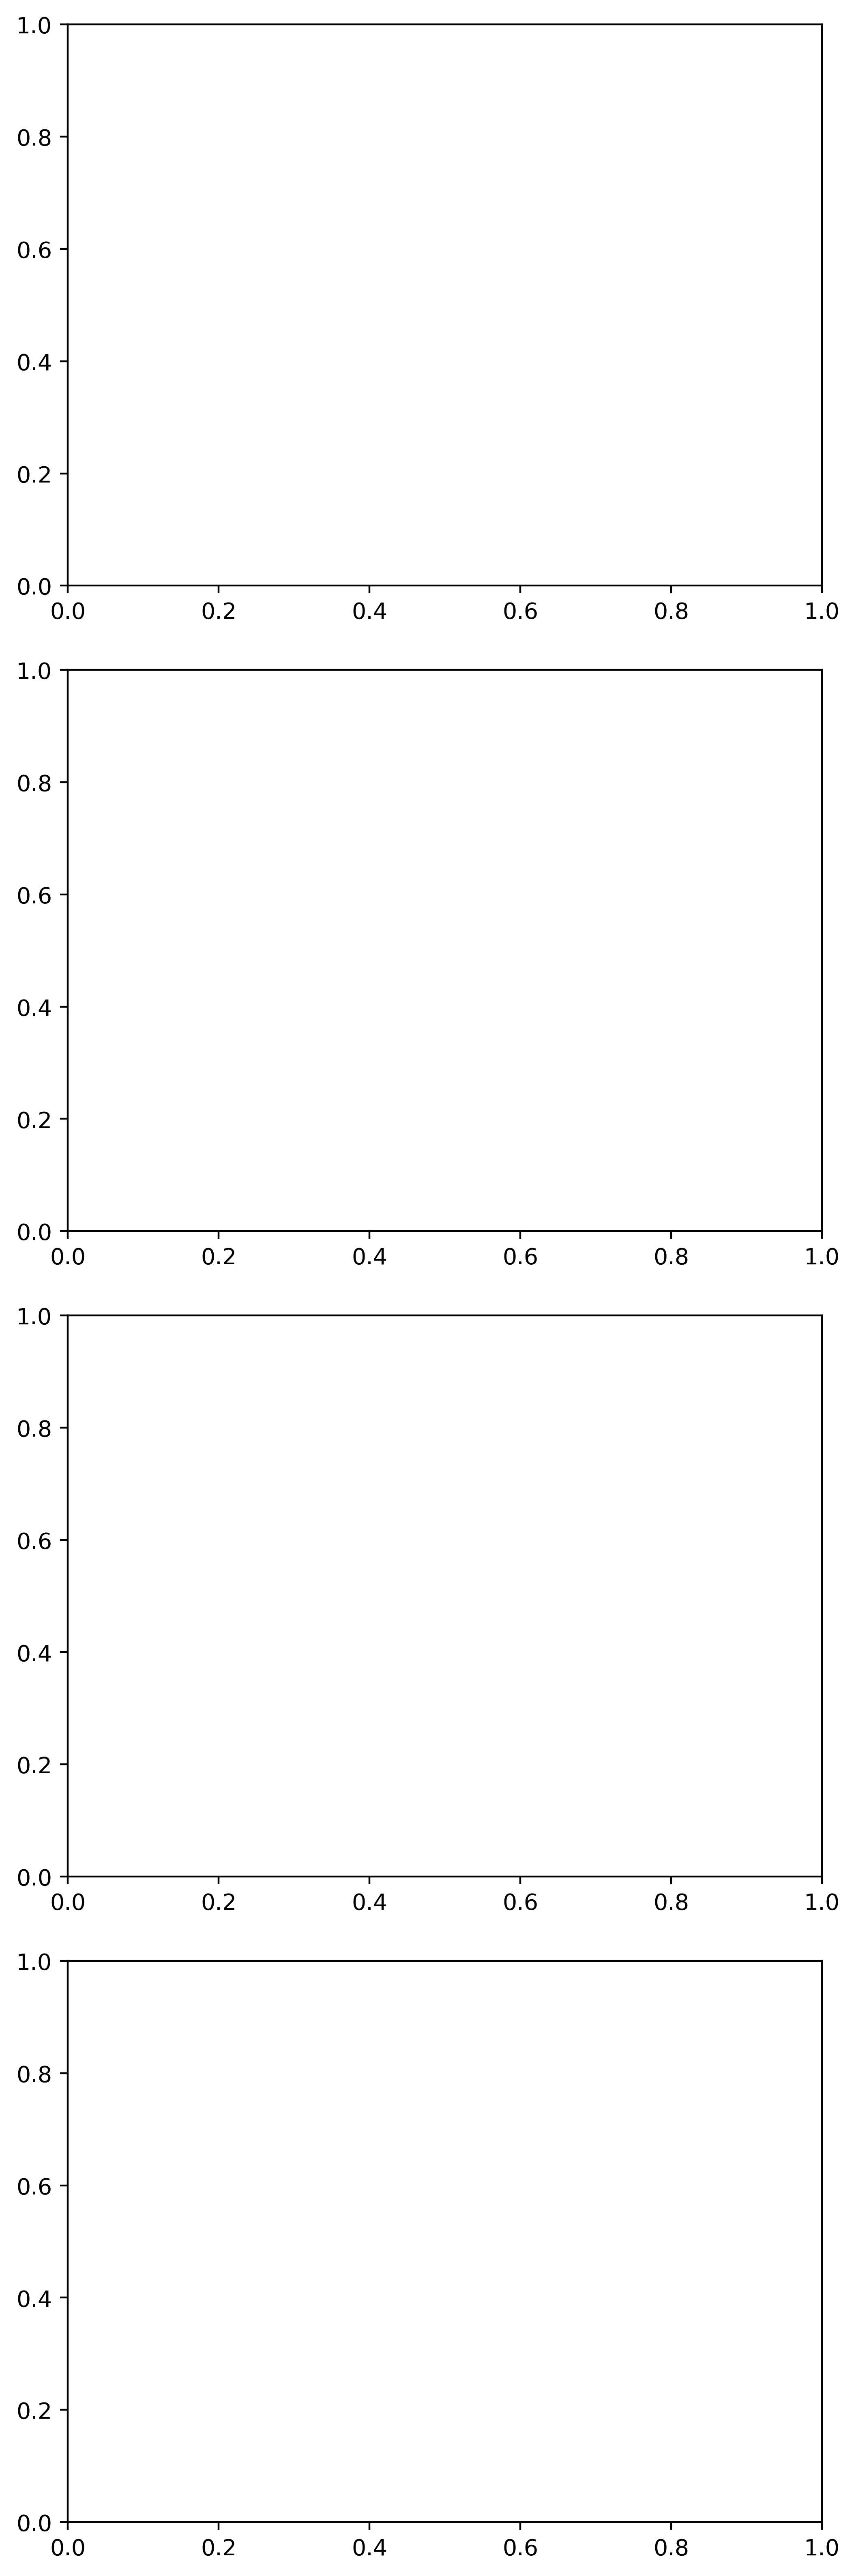

In [ ]:
from sklearn.cluster import KMeans, DBSCAN
from scipy.spatial.distance import cdist
from scipy.stats import skewnorm

def cluster_list(data, n_clusters=None):
    """
    对单个列表进行聚类，返回聚类中心。
    """
    data = np.array(data).reshape(-1, 1)  # 转换为二维数组
    if n_clusters is not None:
        # 使用 KMeans 聚类
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        kmeans.fit(data)
        centers = kmeans.cluster_centers_.flatten()
    else:
        # 使用 DBSCAN 聚类
        dbscan = DBSCAN(eps=10, min_samples=2)
        labels = dbscan.fit_predict(data)
        unique_labels = set(labels) - {-1}  # 忽略噪声点
        centers = np.array([data[labels == label].mean() for label in unique_labels])

    centers = [int(20 + center // 90 * 90) for center in centers]
    return np.sort(centers)

def align_features(all_centers):
    """
    对所有列表的特征值进行全局对齐，返回统一的特征值集合。
    """
    all_centers_flat = np.concatenate(all_centers).reshape(-1, 1)
    kmeans_global = KMeans(n_clusters=len(set(np.round(all_centers_flat.flatten(), decimals=0))), random_state=42)
    kmeans_global.fit(all_centers_flat)
    global_centers = np.sort(kmeans_global.cluster_centers_.flatten())
    return global_centers

def assign_to_global(list_centers, global_centers):
    """
    将列表的特征值映射到全局特征值集合。
    """
    assigned_centers = []
    for center in list_centers:
        closest_center = global_centers[np.argmin(cdist([[center]], global_centers.reshape(-1, 1)))]
        assigned_centers.append(closest_center)
    return np.unique(assigned_centers)

fig, axes = plt.subplots(4, len(mouseNames)+1, figsize = ((len(mouseNames)+1) * 6, 20), dpi = 400)
# if len(mouseNames) == 1:
#     for i in range(len(axes)):
#         axes[i] = [axes[i]]
fig.subplots_adjust(wspace=0.25, hspace=0.15)

nDays:int = np.max([len(MouseDailyRecordClass.Days) for MouseDailyRecordClass in MouseRecords])
DailyColor:list[str]=[]
for i in range(1, nDays + 1):
    tempcolor = i * (255 // nDays)
    DailyColor.append(f"#{tempcolor:02X}{(205 - abs(205 - int(tempcolor * 1.6))):02X}{(255 - tempcolor):02X}")

DistancesEverydayEveryMouse = []
TimeEverydayEveryMouse = []
TimeDetailEverydayEveryMouse = []
hfTimeDetailEverydayEveryMouse = []
TimeEverydayEveryMouseInGroup = []


StayPosEverydayEveryMouse = []
TrialDistanceEverydayEveryMouse = []
TrialhfDistanceEverydayEveryMouse = []
TrialhfDistanceInGroupEverydayEveryMouse = []
for mouse in MouseRecords:
    DistancesEverydayEveryMouse.append(mouse.ReturnDistance())
    TrialhfDistanceInGroupEverydayEveryMouse.append(mouse.ReturnFristHalfDistanceInGroup())
    tempMean = []
    for meandict in mouse.ReturnMean():
        tempMean.append(meandict["trialElapsedTimeMean"])
    TimeEverydayEveryMouse.append(tempMean)
    StayPosEverydayEveryMouse.append(mouse.ReturnTrialMark())
    TimeDetailEverydayEveryMouse.append(mouse.ReturnElaspedTime())
    TimeEverydayEveryMouseInGroup.append(mouse.ReturnElaspedTimeInGroup())
    hfTimeDetailEverydayEveryMouse.append(mouse.ReturnfhElaspedTime())
    TrialDistanceEverydayEveryMouse.append(mouse.ReturnDistance())
    TrialhfDistanceEverydayEveryMouse.append(mouse.ReturnFirstHalfDistance())

for MouseInd in range(0, len(TrialhfDistanceEverydayEveryMouse)):
    meanDistanceInTotal = []
    tempAxeInGroup:plt.Axes = axes[1][MouseInd + 1]
    for day, resultPerDay in enumerate(DistancesEverydayEveryMouse[MouseInd]):
        meanDistanceInTotal.append(np.sum(resultPerDay) / len(resultPerDay) / sceneinfo[2])
        tempAxeInGroup.plot(np.array(TrialhfDistanceInGroupEverydayEveryMouse[MouseInd][day]) / sceneinfo[2], c = DailyColor[day])
    tempAxeInGroup.legend(["day" + str(i) for i in range(1, day + 1)], loc = (0.35, 0.75), ncol = min(3, day//2) if day >= 4 else day)
    tempAxeInGroup.set_ylim(0, 35)

    tempAxe:plt.Axes = axes[0][MouseInd + 1]
    _ap, = tempAxe.plot(meanDistanceInTotal, label = "Distance", c = '#014485')

    meanhfDistanceInTotal = []
    for resultPerDay in TrialhfDistanceEverydayEveryMouse[MouseInd]:
        meanhfDistanceInTotal.append(np.sum(resultPerDay) / len(resultPerDay) / sceneinfo[2])
    _ap1, = tempAxe.plot(meanhfDistanceInTotal, label = "FristHalfDistance", c = '#884dff')
    # tempAxe.plot(np.ones(len(AccuracyInTotal)), linestyle = "--", c = "r")
    # tempAxe.set_ylim(0.5, 1.0)
    tempAxe.tick_params('y', which = 'major', color = '#014485', width = 2, length = 5)
    # tempAxe.set_yticks([])
    tempAxe.set_title(mouseNames[MouseInd])
    tempXticks = []
    for i in range(1, len(meanDistanceInTotal) + 1):
        tempXticks.append(str(i))
    tempAxe.set_xticks(range(len(meanDistanceInTotal)), tempXticks)
    tempAxe.set_yticks(np.arange(0, 28, 2), [f"{value}" for value in np.arange(0, 28, 2)])
    tempAxe.set_ylim(0, 28)
    tempAxe.set_xlabel("Day", size = 15)
    tempAxe.set_ylabel("Distance", size = 12)

    axes[0][0].set_xticks(range(len(meanDistanceInTotal)), tempXticks)
    axes[0][0].set_yticks(np.arange(0, 20, 2), [f"{value}" for value in np.arange(0, 20, 2)])

    axeTime = tempAxe.twinx()
    _tp, = axeTime.plot(TimeEverydayEveryMouse[MouseInd], c = "#018511", label = "Time", alpha = 0.4)
    axeTime.set_ylabel("time(s)", rotation = 270, labelpad = 15, size = 12)
    axeTime.tick_params('y', which = 'major', color = '#018511', width = 2, length = 5)

    if tempAxe == axes[0][1]:
        tempAxe.legend([_ap, _ap1, _tp], [p.get_label() for p in [_ap, _ap1, _tp]])

axes[0][0].set_ylabel("Daily Performance", rotation = 90, size = 15)
axes[0][0].set_xlabel("Day", size = 15)
# axes[0][0].set_ylim(0.5, 1.0)
axes[0][0].set_title("All")
axes[0][0].legend(mouseNames)

    # StayPosDirectionEverydayEveryMouse.append([])
StayPosDirectionEverydayEveryMouse = []
TrialPosMarkEverydayEveryMouse = []
TrialPerformanceEverydayEveryMouse = []
    # TrialPosMarkEverydayEveryMouse.append([])

for StayPosPerMouseInd in range(0, len(StayPosEverydayEveryMouse)):
    StayPosDirectionEverydayEveryMouse.append([])
    TrialPosMarkEverydayEveryMouse.append([])
    StayPosPerDay = []
    EnterPosPerDay = []
    for resultPerDay in StayPosEverydayEveryMouse[StayPosPerMouseInd]:
        StayPosPerDay.append(   pd.DataFrame(([v[0] for v in resultPerDay])))
        EnterPosPerDay.append(  pd.DataFrame([(v[1]) for v in resultPerDay]))
        
    tempAxe:plt.Axes = axes[2][StayPosPerMouseInd + 1]
    tempAxe2:plt.Axes = axes[3][StayPosPerMouseInd + 1]
    
    for day in range(len(EnterPosPerDay)):
        # TrialPosMarkEverydayEveryMouse[StayPosPerMouseInd].append([])
        
        x = EnterPosPerDay[day][0].values
        y = 1080 - np.array(EnterPosPerDay[day][1].values)
        StayPosDirectionEverydayEveryMouse[StayPosPerMouseInd].append(np.array((630 - np.degrees(np.arctan2(np.array(y) - sceneinfo[1], np.array(x) - sceneinfo[0]))) % 360))
        # TrialPosMarkEverydayEveryMouse.append([])

        _ap = tempAxe.scatter(x, y, c = DailyColor[day], s=1, alpha=0.1)
        tempAxe2.scatter([day] * len(x), StayPosDirectionEverydayEveryMouse[StayPosPerMouseInd][day], c = DailyColor[day], s=1, alpha=0.1)

    # tempAxe.plot(np.ones(len(AccuracyInTotal)), linestyle = "--", c = "r")
    tempAxe.set_ylim(150, 1000)
    tempAxe.set_xlim(300, 1200)
    tempAxe.set_aspect(1)
    tempAxe2.set_ylim(0, 360)

    tempAxe.tick_params('y', which = 'major', color = '#014485', width = 2, length = 5)
    # tempAxe.set_yticks([])
    # tempAxe.legend([_ap, _tp], [p.get_label() for p in [_ap, _tp]])

    # tempAxe.set_xticks(range(len(meanDistanceInTotal)), [str(i) for i in range(1, len(meanDistanceInTotal) + 1)])
    # tempAxe.set_yticks(np.arange(1500, 5500, 500), [f"{value}" for value in np.arange(1500, 5500, 500)])
    tempAxe.set_xlabel("Day", size = 15)
    # tempAxe.set_ylabel("Distance", size = 12)
plt.show()


fig, axes = plt.subplots(nDays, len(mouseNames), figsize = ((len(mouseNames)+1) * 8, nDays*4.5))
fig.subplots_adjust(wspace=0.2, hspace=0.2)

selectedfig, selectedaxes = plt.subplots(2, 1, figsize = ( 8, 9))
def select_mouse_day(mouse, day):
    if mouse == 1:
        if day == 1:
            return selectedaxes[0]
        if day == 11:
            return selectedaxes[1]
    return None


tempList = [item for dirList in StayPosDirectionEverydayEveryMouse for item in dirList]
listCenters = [cluster_list(lst, n_clusters=None) for lst in tempList]
TrialPosMarks = list(set([item for dirList in listCenters for item in dirList]))
TrialPosMarks.sort()
def ProjectTrialPosMark(day, dir):
    # if day <= 2:
    #     dir -= 50
    abs_diff = np.abs(np.array(TrialPosMarks) - dir[:, np.newaxis])
    # Find the index of the minimum differences
    closest_indices = np.argmin(abs_diff, axis=1)
    # Return the closest values using the indices
    return np.array(TrialPosMarks)[closest_indices]
    # return min(TrialPosMarks, key=lambda x: abs(x - dir))

for StayPosPerMouseInd in range(0, len(StayPosEverydayEveryMouse)):
    for day in range(len(StayPosEverydayEveryMouse[StayPosPerMouseInd])):
        TrialPosMarkEverydayEveryMouse[StayPosPerMouseInd].append(ProjectTrialPosMark(day, StayPosDirectionEverydayEveryMouse[StayPosPerMouseInd][day]))

TrialDistanceRatioEverydayEveryMouse = []
TrialhfDistanceRatioEverydayEveryMouse = []
TrialhfDistanceRatioEverydayEveryMouse = []
for mouseInd in range(len(MouseRecords)):
    TrialPerformanceEverydayEveryMouse.append([])
    TrialDistanceRatioEverydayEveryMouse.append([])
    TrialhfDistanceRatioEverydayEveryMouse.append([])
    TrialhfDistanceRatioEverydayEveryMouse.append([])
    for day in range(len(MouseRecords[mouseInd].Days)):
 
        hfdata = np.array(TrialhfDistanceEverydayEveryMouse[mouseInd][day]) / sceneinfo[2]
        data = np.array(TrialDistanceEverydayEveryMouse[mouseInd][day]) / sceneinfo[2]
        TrialhfDistanceRatioEverydayEveryMouse[mouseInd].append(hfdata)
        TrialDistanceRatioEverydayEveryMouse[mouseInd].append(data)
        shape, loc, scale = skewnorm.fit(hfdata)
        TrialPerformanceEverydayEveryMouse[mouseInd].append([shape, loc, scale])

        tempAxe:plt.Axes = axes[day][mouseInd] if len(MouseRecords) > 1 else axes[day]
        tempAxe.hist(hfdata, range=(0, 50), bins=50, alpha=0.5, density=True, rwidth= 0.9, label='Distances ratio')
        x = np.linspace(0, 50, 1000)
        pdf = skewnorm.pdf(x, a=shape, loc=loc, scale=scale)
        tempAxe.plot(x, pdf, 'r-', lw=2, label='Theoretical Skew Normal')


        _mean = skewnorm.stats(shape, loc=loc, scale=scale, moments='m')  # 期望值
        skew = skewnorm.stats(shape, loc=loc, scale=scale, moments='s')  # 偏度
        var = skewnorm.stats(shape, loc=loc, scale=scale, moments='v')   # 方差
        tempAxe.annotate(f"mean: {_mean:.2f}\n(small -> better)\nskew: {skew:.2f}\n(big -> better) \nvar: {var:.2f}\n(small -> high consistency)", (20, 0.14), size=15)

        tempSelectedAxe:plt.Axes = select_mouse_day(mouseInd, day)
        if tempSelectedAxe is not None:
            _count, _, _ =  tempSelectedAxe.hist(data, range=(0, 30), bins=30, alpha=0.8, density=True, rwidth= 0.9, label='Distances ratio')
            # x = np.linspace(0, 30, 1000)
            # tempSelectedAxe.plot(x, pdf, 'r-', lw=2, label='Theoretical Skew Normal')
            _h = _count[bisect.bisect_right(_count, np.mean(data)) - 1]
            tempSelectedAxe.plot([np.mean(data)] * 2, [0, _h + 0.5], lw = 2, linestyle = '--', alpha = 0.8, c = 'r')
            tempSelectedAxe.annotate(f"mean: {np.mean(data):.2f}", (np.mean(data) + 1, _h + 0.2), size=15, weight = 'bold')
            tempSelectedAxe.set_xlabel("Normalized Distance", size = 15, weight = 'bold')
            tempSelectedAxe.set_ylabel("Probability", size = 15, weight = 'bold')
            tempSelectedAxe.set_ylim(0, 0.42)

            for label in (tempSelectedAxe.get_xticklabels() + tempSelectedAxe.get_yticklabels()):
                label.set_fontsize(12)
                label.set_fontweight('bold')

    
        if day == 0:
            tempAxe.set_title(mouseNames[mouseInd])
        if mouseInd == 0:
            tempAxe.set_ylabel(f"Day {day}")

        tempAxe.set_ylim(0, 0.27)

plt.show()


In [ ]:
from scipy.stats import wilcoxon
from scipy.stats import ttest_rel

# 执行威尔克逊符号秩检验
before = np.array([np.mean(d[0]) for d in TrialhfDistanceEverydayEveryMouse]) / sceneinfo[2]
after = np.array([np.mean(d[-1]) for d in TrialhfDistanceEverydayEveryMouse]) / sceneinfo[2]
stat, p = wilcoxon(before, after, alternative='greater')  # 单侧检验，检验训练后是否显著提高

print(f"Wilcoxon statistic: {stat}")
print(f"P-value: {p}")

# 解释结果
# alpha = 0.05
# if p < alpha:
#     print("训练显著提高了任务解决能力 (p < 0.05)")
# else:
#     print("训练没有显著提高任务解决能力 (p >= 0.05)")

# 创建图形
plt.figure(figsize=(4, 6))

# 绘制每个实验者的前后得分连线
for i in range(len(before)):
    plt.plot([1, 2], [before[i], after[i]], 
             color='gray', linestyle='--', alpha=0.5)
    
# 绘制前后得分的散点
plt.scatter(np.ones(len(before)), before, 
            color='gray', label='naive', s=100)
plt.scatter(np.ones(len(after))*2, after, 
            color='gray', label='expert', s=100)

# 绘制均值和中位数
# plt.scatter([1, 2], [np.mean(before), np.mean(after)], 
#          c=['b', 'r'])
plt.plot([1, 2], [np.mean(before), np.mean(after)], 
         c='r', linestyle='-', linewidth=2, marker='o', markersize=10, label='mean')
# plt.plot([1, 2], [np.median(before), np.median(after)], 
#          color='green', linestyle='-', linewidth=2, marker='s', markersize=10, label='median')
plt.gca().set_xlim(0.5, 2.5)
plt.gca().set_ylim(0, max(max(before), max(after)) + 5)
plt.gca().spines['right'].set_color('none')
plt.gca().spines['top'].set_color('none')
# # 添加统计信息
# plt.text(1.5, max(after)*1.05, 
#          f'Wilcoxon p = {p:.4f}\n提升中位数: {np.median(before - after)}', 
#          ha='center', fontsize=12)
for label in (plt.gca().get_xticklabels() + plt.gca().get_yticklabels()):
    label.set_fontsize(15)
    label.set_fontweight('bold')
# 美化图形
plt.xticks([1, 2], ['naive', 'expert'])
plt.ylabel('Normalized Distance', size = 12, weight = 'bold')
# plt.ylabel('任务得分')
# plt.title('训练前后任务解决能力比较')
# plt.legend()
# plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
trialEventTime = []
for mouseInd in range(len(MouseRecords)):
    trialEventTime.append([])
    for day in range(len(MouseRecords[mouseInd].Days)):
        trialEventTime[mouseInd].append({})
        trialStartTimes = []
        trialEndTimes = []
        trialFinishTimes = []
        for i, tempDf in enumerate(MouseRecords[mouseInd].Days[day].trials):
            # tempDf:pd.DataFrame = MouseRecords[mouseInd].Days[day].trials[trialInd]
            _startTime = tempDf.loc[tempDf['type'] == 'start']['delta time'].values[0]
            _endTime = tempDf.loc[tempDf['type'] == 'end']['delta time'].values[0]
            _finishTime = tempDf.loc[(tempDf['lickPos'] == '-3')]['delta time'].values[0]
            trialStartTimes.append(_startTime)
            trialEndTimes.append(_endTime)
            trialFinishTimes.append(_finishTime)
        tempDeviceEvent = MouseRecords[mouseInd].Days[day].ReturnDeviceEvents()
        trialEventTime[mouseInd][day]['start'] = np.array(trialStartTimes)
        trialEventTime[mouseInd][day]['startInd'] = np.array(MouseRecords[mouseInd].Days[day].trialIndexes)
        trialEventTime[mouseInd][day]['end'] = np.array(trialEndTimes)
        trialEventTime[mouseInd][day]['finish'] = np.array(trialFinishTimes)
        OGDf = tempDeviceEvent['OGManipulate']
        trialEventTime[mouseInd][day]['OGStart'] = OGDf.loc[OGDf['lickPos'] != '0']['delta time'].values
        MSDf = tempDeviceEvent['miniscopeRecord']
        trialEventTime[mouseInd][day]['MSStart'] = MSDf.loc[MSDf['lickPos'] != '0']['delta time'].values
        #End可能不在文件中记录，对齐后直接判断

            # trialEventTime[mouseInd][day].append((_startTime, _endTime, _finishTime))

In [ ]:
import matplotlib.patches as patches
from scipy import stats
from scipy.stats import bootstrap
import statsmodels.formula.api as smf
from scipy.spatial import cKDTree

def auto_align_with_ratio(ref, noisy, ratio, tolerance):
    if len(ref) == 0 or len(noisy) == 0:
        print("Empty input")
    
    ref = np.asarray(ref)
    noisy = np.asarray(noisy)
    refdiff:np.ndarray = np.diff(ref) * ratio
    # noisydiff = np.diff(noisy)
    refdiffReverse = np.flip(refdiff)

    diffDiff = []
    for noise in noisy[(len(ref) - 1):]:
        tempRes = [noise]
        minused = noise
        for rdiff in refdiffReverse:
            minused = minused - rdiff
            tempRes.append(minused)

        diffDiff.append(np.flip(tempRes))

    indicesMatch = []
    indicesMatchDiff = []
    for noisyMinusDiff in diffDiff:
        tempindicesMatch = []
         
        for minusedDiff in noisyMinusDiff:
        # 检查数据数组中是否存在一个元素在 ref ± tolerance 范围内
            found = any(abs(d - minusedDiff) <= tolerance for d in noisy)
            if not found:
                break
        else:
            for rightMinusedDiff in noisyMinusDiff:
                indices = np.asarray([i for i, d in enumerate(noisy) if abs(d - rightMinusedDiff) <= tolerance])
                if len(indices) == 1:
                    tempindicesMatch.append(indices[0])
                else:
                    matchdiff = abs(noisy[indices] - rightMinusedDiff)#对当前潜在预测找到原始数据中最符合潜在预测的值
                    tempindicesMatch.append(indices[np.where(matchdiff == min(matchdiff))[0][0]])
        indicesMatch.append(tempindicesMatch)
        if len(tempindicesMatch) == len(ref):
            indicesMatchDiff.append(np.sum(abs(noisy[np.array(tempindicesMatch)] - ref * ratio)))
        else:
            indicesMatchDiff.append(-1)
    
    indicesMatchDiff = np.asarray(indicesMatchDiff)
    if np.all(indicesMatchDiff < 0):
        print("No match found")
    bestMatchInd = np.where(indicesMatchDiff == min(indicesMatchDiff[indicesMatchDiff >= 0]))[0][0]
    bestMatch = indicesMatch[bestMatchInd]
    
    return bestMatch


def AlignProjectBackToUnityTime(timesInLogevent, offsetInLogevent, scale = 50000)-> np.ndarray:
    return (np.asarray(timesInLogevent) - offsetInLogevent) / scale

def ResampleByStartTime(eventStart, eventIndex, manipulateStart, manipulateEnd, tolerance = 0.2):
    """
    找出控制时间段内发生的目标事件及其标签
    
    参数:
        eventStart: 目标事件开始时间列表
        eventIndex: 目标事件标签列表(与target_starts长度相同)
        manipulateStart: 控制事件开始时间列表
        manipulateEnd: 控制事件结束时间列表
    
    返回:
        一个列表，每个元素是一个元组，包含:
        (控制时间段索引, 该控制时间段内发生的目标事件索引列表, 对应的标签列表)
    """
    # 首先确保输入数据长度匹配
    assert len(eventStart) == len(eventIndex), "目标事件开始时间和标签列表长度不一致"
    assert len(manipulateStart) == len(manipulateEnd), "控制事件开始和结束时间列表长度不一致"
    
    result = []
    
    # 遍历每个控制时间段

    for control_idx, (ctrl_start, ctrl_end) in enumerate(zip(manipulateStart, manipulateEnd)):
        # 检查时间有效性
        if ctrl_start > ctrl_end:
            continue  # 或者可以抛出异常，取决于你的需求
            
        # 存储当前控制时间段内的目标事件索引和标签
        target_indices = []
        # half_target_indices = []
        target_labels_in_period = []
        
        # 检查每个目标事件是否在当前控制时间段内
        for target_idx, (t_start, label) in enumerate(zip(eventStart, eventIndex)):
            if t_start - ctrl_start > tolerance * -1 and t_start < ctrl_end:
                target_indices.append(target_idx)
                target_labels_in_period.append(label)
            # elif target_idx :
        # 添加到结果中
        # result.append((control_idx, target_indices, target_labels_in_period))
        result += target_labels_in_period
    
    return result

splitAtDay = 6
columns = 3
figs=[]
axeses=[]
if nDays % splitAtDay == 1:
    splitAtDay += 1
for i in range(0, ceil(nDays / splitAtDay)):
    lineCount = min(splitAtDay, nDays - i *splitAtDay)
    _fig, _axes = plt.subplots(lineCount, len(mouseNames)*columns, figsize = (len(mouseNames) * 8 * columns, lineCount * 4), dpi = 300)
    figs.append(_fig)
    fig.subplots_adjust(wspace=0.2, hspace=0.15)

    axeses.append(_axes)

# showFig, showAxe = plt.subplots(1, 1, figsize = (6, 4), dpi = 300)

# fig, axes = plt.subplots(nDays, len(mouseNames)*2, figsize = (len(mouseNames) * 8, nDays * 4), dpi = 600)
# fig.subplots_adjust(wspace=0.2, hspace=0.15)
AllMouseOGTrials = []
AllMouseMSTrials = []
AllMouseMSFrameInPosDfIndex = []
AllMouseMSFrameInBaslerFrameIndex = []
OGResults = []
for mouseInd in range(0, len(TrialhfDistanceEverydayEveryMouse)):
# for mouseInd in range(0, 1):
    AllMouseOGTrials.append([])
    AllMouseMSTrials.append([])
    AllMouseMSFrameInPosDfIndex.append([])
    AllMouseMSFrameInBaslerFrameIndex.append([])
    OGResults.append([])
    for day, resultPerDay in enumerate(DistancesEverydayEveryMouse[mouseInd]):
        OGResults[mouseInd].append([])
        figIndex = day // splitAtDay

        DayClassInstance:Day = MouseRecords[mouseInd].Days[day]
        eventDict = DayClassInstance.fullEventRecord
        OGTrials = []
        MSTrials = []
        MSFrameInPosDfIndex = []
        MSFrameInBaslerFrameIndex = []
        if eventDict is not None:
            trialEventTimeNow = trialEventTime[mouseInd][day]
            try:
                if mouseInd == 1 and day == 11:
                    print("test")
                trialStartAlign = auto_align_with_ratio(
                    trialEventTimeNow['start'],
                    eventDict['VisualStimulate']['Time_E'],
                    ratio=50000,
                    tolerance=25000
                )
                trialStartTimeInLogevent = np.asarray(eventDict['VisualStimulate']['Time_E'])[np.array(trialStartAlign)]
                rescale = (trialStartTimeInLogevent[-1] - trialStartTimeInLogevent[0]) / (trialEventTimeNow['start'][-1] - trialEventTimeNow['start'][0])

                trialFinishAlign = auto_align_with_ratio(
                    trialEventTimeNow['finish'],
                    eventDict['VisualStimulate']['Time_S'],
                    ratio=rescale,
                    tolerance=20000
                )
                trialFinishTimeInLogevent = np.asarray(eventDict['VisualStimulate']['Time_S'])[np.array(trialFinishAlign)]
                startTime = trialEventTimeNow['start'][0]
                lastfinishTime = trialEventTimeNow['finish'][-1]
                startEventTime = trialStartTimeInLogevent[0]
                lastfinishEventTime = np.array(eventDict['VisualStimulate']['Time_S'])[np.array(trialFinishAlign)][-1]
                offset = (startEventTime - startTime*rescale + lastfinishEventTime - lastfinishTime*rescale) * 0.5
                endEventTime = trialEventTimeNow['end'][-1] * rescale + offset
                print(f"mouse {mouseInd} day {day} offset: {offset}")
                
                # trialIndexes = trialEventTimeNow['startInd']

                if len(eventDict['OgEnable']['Time_S']) > 2:
                    # validOGStartTime = [v for v in trialEventTimeNow['OGStart'] if v > startTime]

                    # trialOGAlign = aligned_indices = auto_align_with_ratio(
                    #     validOGStartTime,
                    #     eventDict['OgEnable']['Time_S'],
                    #     ratio=50000,
                    #     tolerance=10000
                    # )
                    OGStartTimeInLogevent = np.array(eventDict['OgEnable']['Time_S'])
                    OGStartTimeInLogevent = OGStartTimeInLogevent[((OGStartTimeInLogevent > startEventTime) & (OGStartTimeInLogevent < endEventTime))]
                    # OGStartTime = AlignProjectBackToUnityTime(eventDict['OgEnable']['Time_S'], offset)
                    # OGStartTime = OGStartTime[((OGStartTime > (startTime - 0.5)) & (OGStartTime < (endTime + 0.5)))]
                    OGEndTimeInLogevent = np.array(eventDict['OgEnable']['Time_E'])
                    OGEndTimeInLogevent = OGEndTimeInLogevent[((OGEndTimeInLogevent > OGStartTimeInLogevent[0]) & (OGEndTimeInLogevent < endEventTime))]
                    # OGEndTime = AlignProjectBackToUnityTime(eventDict['OgEnable']['Time_E'], offset)
                    # OGEndTime = OGEndTime[((OGEndTime > OGStartTime[0]) & (OGEndTime < (endTime + 0.5)))]
                    # if len(OGStartTime) - len(OGEndTime) == 1:
                    #     OGEndTime = np.append(OGEndTime, endTime)
                    if len(OGEndTimeInLogevent) > len(OGStartTimeInLogevent):
                        OGEndTimeInLogevent = OGEndTimeInLogevent[:len(OGStartTimeInLogevent)]
                    if len(OGStartTimeInLogevent) - len(OGEndTimeInLogevent) == 1:
                        OGEndTimeInLogevent = np.append(OGEndTimeInLogevent, endEventTime)

                    # validOGEndTime = [v for v in validOGEndTime if v > startTime]
                    print(f"mouse {mouseInd} day {day} OG aligned")

                    # res = ResampleByStartTime(trialEventTimeNow['start'], trialIndexes, OGStartTime, OGEndTime)
                    res = ResampleByStartTime(trialStartTimeInLogevent, np.array(range(len(trialStartTimeInLogevent))), OGStartTimeInLogevent, OGEndTimeInLogevent)
                    # print(res)
                    # if len(res) :
                    finish_res = ResampleByStartTime(trialFinishTimeInLogevent, np.array(range(len(trialFinishTimeInLogevent))), OGStartTimeInLogevent, OGEndTimeInLogevent)
                    finish_res = np.array(finish_res) + 1
                        

                    OGTrials = res if len(res) > len(finish_res) else finish_res
                    print(OGTrials)

                if len(trialEventTimeNow['MSStart']):
                    # trialMSAlign = aligned_indices = auto_align_with_ratio(
                    #     [v for v in trialEventTimeNow['MSStart'] if v > startTime],
                    #     eventDict['MsEnable']['Time_S'],
                    #     ratio=50000,
                    #     tolerance=10000
                    # )
                    # print(f"mouse {mouseInd} day {day} MS aligned")
                    baslerSyncTick = np.array(eventDict['BaslerSync']['Time_E'])
                    msSyncTick = np.array(eventDict['MsSync']['Time_E'])
                    # tree = cKDTree(baslerSyncTick.reshape(-1, 1))
                    # _, indices = tree.query(msSyncTick.reshape(-1, 1))
                    msFrameIndices = cKDTree(baslerSyncTick.reshape(-1, 1)).query(msSyncTick.reshape(-1, 1))[1]
                    MSStartTimeInLogevent = np.array(eventDict['MsEnable']['Time_S'])
                    MSStartTimeInLogevent = MSStartTimeInLogevent[((MSStartTimeInLogevent > startEventTime) & (MSStartTimeInLogevent < endEventTime))]
                    # OGStartTime = AlignProjectBackToUnityTime(eventDict['OgEnable']['Time_S'], offset)
                    # OGStartTime = OGStartTime[((OGStartTime > (startTime - 0.5)) & (OGStartTime < (endTime + 0.5)))]
                    MSEndTimeInLogevent = np.array(eventDict['MsEnable']['Time_E'])
                    MSEndTimeInLogevent = MSEndTimeInLogevent[((MSEndTimeInLogevent > MSStartTimeInLogevent[0]) & (MSEndTimeInLogevent < endEventTime))]

                    MSFrameTime = AlignProjectBackToUnityTime(eventDict['MsSync']['Time_E'], offset, rescale)
                    correspondPosDfIndex = DayClassInstance.GetPosOrIndAtTime(MSFrameTime, needInd=True)
                    for _icorr in range(1, len(correspondPosDfIndex)):
                        correspondPosDfIndex[_icorr] = max(correspondPosDfIndex[_icorr], correspondPosDfIndex[_icorr - 1] + 1) if correspondPosDfIndex[_icorr] != 0 else 0

                    correspondBaslerFrameIndex = DayClassInstance.PosMainDf.loc[correspondPosDfIndex]['frameInd'].values
                    if correspondPosDfIndex[0] == 0:
                        validInd = np.array(correspondPosDfIndex)
                        validInd = validInd[validInd > 0]
                        dropedFrameCount = len(correspondPosDfIndex) - len(validInd)
                        # MSStartFrameInRec = DayClassInstance.PosMainDf[validInd[0]]['frameInd']#得到对应帧的索引
                        # MSStartFrameInBasler = baslerSyncTick.searchsorted(eventDict['MsSync']['Time_E'][dropedFrameCount])
                        # baslerSyncOffset = MSStartFrameInBasler - MSStartFrameInRec
                        # # MSStartFrameInLogevent = msSyncTick[dropedInd]#得到对应帧在logevent中的时间
                        # # MSStartFrameInBasler = baslerSyncTick.searchsorted(MSStartFrameInLogevent)#得到对应帧在basler中的帧索引
                        # dropedInd = DayClassInstance.GetPosOrIndAtTime(eventDict['MsSync']['Time_E'][:dropedFrameCount], refTimes=baslerSyncTick, needInd=True)
                        correspondBaslerFrameIndex[:dropedFrameCount] = 0#丢失的帧设为0

                    MSFrameInPosDfIndex = np.array(correspondPosDfIndex)
                    MSFrameInBaslerFrameIndex = np.array(correspondBaslerFrameIndex)

                    # OGEndTime = AlignProjectBackToUnityTime(eventDict['OgEnable']['Time_E'], offset)
                    # OGEndTime = OGEndTime[((OGEndTime > OGStartTime[0]) & (OGEndTime < (endTime + 0.5)))]
                    # if len(OGStartTime) - len(OGEndTime) == 1:
                    #     OGEndTime = np.append(OGEndTime, endTime)
                    if len(MSEndTimeInLogevent) > len(MSStartTimeInLogevent):
                        MSEndTimeInLogevent = MSEndTimeInLogevent[:len(MSStartTimeInLogevent)]
                    if len(MSStartTimeInLogevent) - len(MSEndTimeInLogevent) == 1:
                        MSEndTimeInLogevent = np.append(MSEndTimeInLogevent, endEventTime)

                    res = ResampleByStartTime(trialStartTimeInLogevent, np.array(range(len(trialStartTimeInLogevent))), MSStartTimeInLogevent, MSEndTimeInLogevent)
                    print(res)
                    MSTrials = res

            except Exception as e:
                print(f"mouse {mouseInd} day {day} logevent align failed",e)

        fhdistanceplot = np.array(TrialhfDistanceRatioEverydayEveryMouse[mouseInd][day])
        distanceplot = np.array(TrialDistanceRatioEverydayEveryMouse[mouseInd][day])
        lhdistanceplot = distanceplot - fhdistanceplot
        timeplot = np.array(TimeDetailEverydayEveryMouse[mouseInd][day]) / np.mean(TimeDetailEverydayEveryMouse[mouseInd][day])
        fhtimeplot = np.array(hfTimeDetailEverydayEveryMouse[mouseInd][day]) / np.mean(hfTimeDetailEverydayEveryMouse[mouseInd][day])
        lftimeplot = fhtimeplot - timeplot
        trialCount = len(fhtimeplot) if len(set([len(fhdistanceplot), len(distanceplot), len(fhtimeplot), len(timeplot)])) == 1 else -1
        if trialCount == -1:
            print(f"mouse {mouseInd} day {day} trial count not match")
            continue

        tempAxeInGroup:plt.Axes = axeses[figIndex][day - figIndex * splitAtDay][mouseInd*columns]
        tempAxeInGroup.plot(fhdistanceplot, c = 'black', label = "Normalized Distance", lw=0.6, alpha = 0.9)
        tempAxeInGroup.set_ylim(0, 35)
        tempAxeInGroup.set_ylabel("Normalized Distance", rotation = 90, labelpad = 7, size = 10, weight = 'bold')

        # if mouseInd == 0 and day == 20:
        #     showAxe.plot(fhdistanceplot[25:75], c = 'black', label = "Normalized Distance", lw=1, alpha = 1)
        #     showAxe.set_ylim(0, 35)
        #     showAxe.set_ylabel("Normalized Distance", rotation = 90, labelpad = 7, size = 12, weight = 'bold')
        #     for og in OGTrials:
        #         if og >= 25 and og < 75:
        #             showAxe.add_patch(patches.Rectangle((og-25, 0), 1, 35, alpha = 0.4, color='b'))
        # axeTime = tempAxeInGroup.twinx()
        # axeTime.plot(np.array(TimeDetailEverydayEveryMouse[mouseInd][day]) / 5, c = 'blue', label = "Time", alpha = 0.5, lw=0.6)
        # axeTime.set_ylabel("time(s)", rotation = 270, labelpad = 8, size = 10, weight = 'bold')
        # axeTime.set_ylim(0, 35)
        # axeTime.set_yticks(np.arange(0, 35, 3), [f"{_s * 5}" for _s in np.arange(0, 35, 3)], weight = 'bold')
        # lines, labels = tempAxeInGroup.get_legend_handles_labels()
        # lines2, labels2 = axeTime.get_legend_handles_labels()
        # tempAxeInGroup.legend(lines + lines2, labels + labels2, loc = 0)
        # tempAxeInGroup.legend()
        # OGLine = np.zeros_like(hfplot)
        # OGLine[np.array(OGTrials)] = 2
        # MSLine = np.zeros_like(hfplot)
        # MSLine[np.array(MSTrials)] = 1
        for og in OGTrials:
            tempAxeInGroup.add_patch(patches.Rectangle((og, 0), 1, 35, alpha = 0.2, color='b'))
        for ms in MSTrials:
            tempAxeInGroup.add_patch(patches.Rectangle((ms, 0), 1, 35, alpha = 0.2, color='b'))
    # tempAxeInGroup.legend(["day" + str(i) for i in range(1, day + 1)], loc = (0.35, 0.75), ncol = min(3, day//2) if day >= 4 else day)
        for label in (tempAxeInGroup.get_xticklabels() + tempAxeInGroup.get_yticklabels()):
            label.set_fontsize(12)
            label.set_fontweight('bold')
        

        if len(OGTrials) or len(MSTrials):
            tempAxebar:plt.Axes = axeses[figIndex][day - figIndex * splitAtDay][mouseInd*columns+1]
            tempAxeStati:plt.Axes = axeses[figIndex][day - figIndex * splitAtDay][mouseInd*columns+2]

            tempAxebarInvert = tempAxebar.twinx()
            tempAxebarInvert.invert_yaxis()
            labels = ['control', f'with {("OG" if len(OGTrials) else "MS")}']
            tempTrialOffset = [0, 1, 2] 
            tempTrialLength = [0, 1, 2]
            maxoffsetCount = len(tempTrialOffset) * len(tempTrialLength) + (len(tempTrialOffset) - 1)
            width = 0.75 / maxoffsetCount
            ymax = 30
            barColors = []
            TrialoffsetLengthSelect = [[0, 0]]#tempTrialOffset[0], tempTrialLength[0]]
            TrialoffsetLengthGnerate = []
            for i in range(1, maxoffsetCount + 1):
                tempcolor = i * (255 // maxoffsetCount)
                barColors.append(f"#{tempcolor:02X}{(205 - abs(205 - int(tempcolor * 1.6))):02X}{(255 - tempcolor):02X}")
            for _io, trialoffset in enumerate(tempTrialOffset):
                TrialoffsetLengthGnerate.append([])
                for _il, triallength in enumerate(tempTrialLength):
                    tempManipulateTrial = np.array(OGTrials if len(OGTrials) else MSTrials) + trialoffset
                    for repeat in range(triallength):
                        tempManipulateTrial = np.concatenate((tempManipulateTrial, tempManipulateTrial + 1))
                    tempManipulateTrial = np.unique(tempManipulateTrial[tempManipulateTrial < trialCount])
                    tempManipulateTrial.sort()
                    TrialoffsetLengthGnerate[_io].append(tempManipulateTrial)

                    _barId = _io * (len(tempTrialLength) + 1) + _il
                    _baroffset = _barId - 0.5 * maxoffsetCount
                    for _ip, distanceplotData in enumerate([fhdistanceplot, lhdistanceplot, distanceplot]):
                        tempdistanceAffected = distanceplotData[tempManipulateTrial]
                        tempdistanceControl = distanceplotData[np.setdiff1d(np.array(range(tempManipulateTrial[0] if len(MSTrials) ==0 else 50 , trialCount)), tempManipulateTrial)]
                        tempAxebar.bar([_baroffset * width - 0.025*_ip, 1+ _baroffset * width - 0.025*_ip], [np.mean(tempdistanceControl), np.mean(tempdistanceAffected)], width*0.7, yerr=[np.std(tempdistanceControl), np.std(tempdistanceAffected)], color = barColors[_barId], error_kw = {"elinewidth":0.4})
                    for _ip, timeplotData in enumerate([fhtimeplot, lftimeplot, timeplot]):
                        temptimeAffected = timeplot[tempManipulateTrial]
                        temptimeControl = timeplot[np.setdiff1d(np.array(range(trialCount)), tempManipulateTrial)]
                        tempAxebarInvert.bar([_baroffset * width +0.05 - 0.025*_ip, 1+ _baroffset * width +0.05 - 0.025*_ip], [np.mean(temptimeControl) * ymax * 0.1, np.mean(temptimeAffected) * ymax * 0.1], width*0.8, yerr=[np.std(temptimeControl) * ymax * 0.1, np.std(temptimeAffected) * ymax * 0.1], color = barColors[_barId], error_kw = {"elinewidth":0.4})
            
            tempAxebar.set_ylim(0, ymax)
            tempAxebar.set_xticks([0, 1], labels)
            tempAxebar.set_ylabel("distance", rotation = 90, labelpad = 7, size = 15)
            tempAxebarInvert.set_ylim(ymax, 0)
            tempAxebarInvert.set_ylabel("time scaled", rotation = 270, labelpad = 7, size = 15)
            tempAxebarInvert.set_yticks([])
            
            unitlength = 1/len(TrialoffsetLengthSelect)
            # tempAxeStati.set_ylim(-1, tempHight)

            for _is, select in enumerate(TrialoffsetLengthSelect):
                trialSelect = TrialoffsetLengthGnerate[select[0]][select[1]]
                trialSelectcontrol = np.setdiff1d(np.array(range(trialSelect[0], trialCount)), trialSelect)
                # labels:list[str] = ["fhdistanceplot", "lhdistanceplot", "distanceplot", "fhtimeplot", "lhtimeplot", "timeplot"]
                # labels:list[str] = ["Trajectory Length to Target", "Full Trajectory Length"]
                labels:list[str] = ["Trajectory Length to Target", "Time to Target"]
                childunitlength = unitlength / len(labels)
                drawcenters = []
                # for _id, data in enumerate([fhdistanceplot, lhdistanceplot, distanceplot, fhtimeplot, lhdistanceplot, timeplot]):
                tempHight = 0
                for _id, data in enumerate([fhdistanceplot, fhtimeplot]):

                    drawcenter = _is*unitlength + 0.1 + (_id + 0.5)*childunitlength*0.9
                    barwidth = childunitlength * 0.9
                    t_stat, p_value = stats.ttest_ind(data[trialSelectcontrol], data[trialSelect])
                    if p_value > 0.01:
                        print(f"{labels[_id]} 独立t检验结果不显著")
                    # print(f"{labels[_id]}独立t检验结果: t={t_stat:.3f}, p={p_value:.4f}")
                    ci_low, ci_high = bootstrap_result = bootstrap(
                        (data[trialSelect], data[trialSelectcontrol]),
                        statistic=lambda stim, control: np.median(stim) - np.median(control),
                        n_resamples=3000,
                        paired=False,
                        confidence_level=0.95,
                        random_state=41
                    ).confidence_interval

                    # tempAxeStati.bar(drawcenter, ci_low, barwidth)
                    # tempAxeStati.plot((0, 0), lw = 1.2, color = 'black')
                    tempAxeStati.violinplot([data[trialSelectcontrol], data[trialSelect]], positions=[drawcenter - barwidth* 0.2, drawcenter+ barwidth* 0.2], widths=[barwidth*0.2, barwidth*0.2])
                    OGResults[mouseInd][day].append([data[trialSelectcontrol], data[trialSelect]])
                    drawcenters += [drawcenter - barwidth* 0.2, drawcenter + barwidth* 0.2]

                    tempHight = max(max(data), tempHight)
                    _barId = select[0] * (len(tempTrialLength) + 1) + select[1]
                    _baroffset = _barId - 0.5 * maxoffsetCount
                    _barPos = 1+ _baroffset * width - 0.025*(_id % 3)
                    _invertbarPos = _barPos + 0.05
                    # if ci_low > 0:
                    #     tempAxeStati.annotate(f"*  --ci_low = {ci_low:.3f}", (drawcenter - 0.2, tempHight + 2))
                    #     # tempAxeStati.set_ylim(-1, tempHight)
                    # else:
                    #     tempAxeStati.annotate(f"/  --ci_low = {ci_low:.3f}", (drawcenter - 0.2, tempHight + 2))
                    if "Length" in labels[_id]:
                        tempAxebar.annotate("*" if ci_low > 0 else "/", (_barPos, np.mean(data[trialSelect]) + 2))
                    else:
                        tempAxebarInvert.annotate("*" if ci_low > 0 else "/", (_invertbarPos, np.mean(data[trialSelect]) * ymax * 0.1 + 2))
                
                tempAxeStati.set_ylim(0, tempHight + 5)
                tempAxeStati.set_xticks(drawcenters, ["off", "on"] * 2)
                tempAxeStati.set_ylabel("Normalized Distance", rotation = 90, labelpad = 7, size = 15, weight = 'bold')
                for label in (tempAxeStati.get_xticklabels() + tempAxeStati.get_yticklabels()):
                    label.set_fontsize(14)
                    label.set_fontweight('bold')
                
        AllMouseOGTrials[mouseInd].append(OGTrials)
        AllMouseMSTrials[mouseInd].append(MSTrials)
        AllMouseMSFrameInPosDfIndex[mouseInd].append(MSFrameInPosDfIndex)
        AllMouseMSFrameInBaslerFrameIndex[mouseInd].append(MSFrameInBaslerFrameIndex)
            
        # axeTime.tick_params('y', which = 'major', color = '#018511', width = 2, length = 5)
for i, _fig in enumerate(figs):
    _fig.savefig(f"tempOutput/OG_MSfig{i}.pdf")
    _fig.show()
# showFig.show()

In [ ]:
OGResults = [res for res in OGResults if len(res) > 2]

In [ ]:
OGResultsMeans = []
for i, mouse in enumerate(OGResults):
    OGResultsMeans.append([])
    for day in mouse:
        if len(day) > 0:
            OGResultsMeans[i].append([np.mean(arr) for arr in day[0]] + [np.mean(arr) for arr in day[1]])

In [ ]:
data_list = []

# 遍历每个受试者（mouse）
for subject_id, mouse in enumerate(OGResultsMeans):
    # 遍历该受试者的每一天
    for day, _dayres in enumerate(mouse, start=1):  # 天数从1开始编号
        before = _dayres[2]
        after = _dayres[3]
        # 添加正常状态数据
        data_list.append({
            'subject': subject_id + 1,  # 受试者ID从1开始
            'day': day,
            'condition': 'normal',
            'performance': before
        })
        # 添加刺激状态数据
        data_list.append({
            'subject': subject_id + 1,
            'day': day,
            'condition': 'stimulus',
            'performance': after
        })

# 转换为DataFrame
data = pd.DataFrame(data_list)
data["group"] = "treated"  # 默认标记为处理组
data.loc[data["subject"] == 5, "group"] = "control"

In [ ]:
import statsmodels.formula.api as smf

# 定义模型
model = smf.mixedlm(
    formula="performance ~ group * condition",  # 固定效应：condition
    data=data,
    groups=data["subject"],            # 随机效应：按subject分组
    re_formula="~1"                     # 随机截距模型
)

# 拟合模型
result = model.fit()

# 输出结果
print(result.summary())

In [ ]:
import seaborn as sns
plt.figure(figsize=(10, 6))

# 1. 绘制箱线图
sns.boxplot(
    x='subject',
    y='performance',
    hue='condition',
    data=data,
    palette={'normal': 'blue', 'stimulus': 'red'},
    width=0.6
)

# 2. 添加受试者内的连接线（显示个体差异）
# 计算每个受试者的正常/刺激均值
mean_data = data.groupby(['subject', 'condition'])['performance'].mean().reset_index()
# 绘制连接线
for sub in mean_data['subject'].unique():
    sub_data = mean_data[mean_data['subject'] == sub]
    normal_mean = sub_data[sub_data['condition'] == 'normal']['performance'].values[0]
    stim_mean = sub_data[sub_data['condition'] == 'stimulus']['performance'].values[0]
    plt.plot(
        [sub-1.2, sub-0.8],  # 调整位置匹配箱线图
        [normal_mean, stim_mean],
        color='gray',
        linestyle='--',
        alpha=0.6
    )

# 3. 添加显著性标注
plt.text(
    x=1.5, y=data['performance'].max() - 0.5,
    s='Mixed Model: Stimulus > Normal (p < 0.001)',
    ha='center',
    fontsize=12,
    color='green',
    weight='bold'
)

# plt.xlabel('Subject', fontsize = 18, weight = 'bold')
plt.ylabel('Performance', fontsize = 18)
plt.gca().set_xticks(list(range(5)), ['1_9', '1_10', '1_11', '1_12', 'control'])
plt.title('Stimulation Effect with Individual Differences', fontsize = 18)
plt.legend(title='Condition')
plt.tight_layout()
for label in (plt.gca().get_xticklabels() + plt.gca().get_yticklabels()):
    label.set_fontsize(15)
    # label.set_fontweight('bold')
plt.show()

In [ ]:
from scipy.stats import shapiro

def drawPairTest(before, after, alternative='less', axes = None, method:tuple[r't-test', r"wilcoxon"] = 't-test', xticks = []) -> tuple[plt.Figure, plt.Axes]:
    if method == 't-test':
        stat, p = ttest_rel(before, after)
        _stat, _p = shapiro(before)
        print(f"before Shapiro-Wilk统计量: {_stat:.4f}, p值: {_p:.4f}")
        _stat, _p = shapiro(after)
        print(f"after Shapiro-Wilk统计量: {_stat:.4f}, p值: {_p:.4f}")
    elif method == 'wilcoxon':
        stat, p = wilcoxon(before, after, alternative=alternative)
    else:
        return None, None
    if len(xticks) < 2:
        xticks = ['Before', 'After']

    print(f'{'Wilcoxon' if method == 'wilcoxon' else 't-test'} statistic: {stat:.4f}, p-value: {p:.4f}')
    if axes is None:
        _fig, axe = plt.subplots(figsize=(10, 6))
    else:
        _fig, axe = (None, axes)
    for i in range(len(before)):
        axe.plot([0, 1], [before[i], after[i]], 
                color='gray', linestyle='--', alpha=0.5)
        
    # 绘制前后得分的散点
    axe.scatter(np.zeros(len(before)), before, 
                color='gray', label='naive', s=100)
    axe.scatter(np.ones(len(after)), after, 
                color='gray', label='expert', s=100)

    # 绘制均值和中位数
    # plt.scatter([1, 2], [np.mean(before), np.mean(after)], 
    #          c=['b', 'r'])
    axe.plot([0, 1], [np.mean(before), np.mean(after)], 
            c='r', linestyle='-', linewidth=2, marker='o', markersize=10, label='mean')
    # plt.plot([1, 2], [np.median(before), np.median(after)], 
    #          color='green', linestyle='-', linewidth=2, marker='s', markersize=10, label='median')
    axe.set_ylim(min(min(before), min(after)) - 0.5, max(max(before), max(after)) + 1)
    axe.set_xlim(-0.5, 1.5)
    axe.spines['right'].set_color('none')
    axe.spines['top'].set_color('none')
    axe.set_xticks([0, 1],xticks[:2])
    # # 添加统计信息
    # plt.text(1.5, max(after)*1.05, 
    #          f'Wilcoxon p = {p:.4f}\n提升中位数: {np.median(before - after)}', 
    #          ha='center', fontsize=12)
    for label in (axe.get_xticklabels() + axe.get_yticklabels()):
        label.set_fontsize(15)
        label.set_fontweight('bold')
    # 美化图形
    if axes is None:
        plt.show()
    return _fig, axe

In [ ]:
distancePair = {'before': [], 'after': []}
timePair = {'before': [], 'after': []}
_, axes = plt.subplots(1, 2, figsize=(8, 5), dpi = 150)
for mouse in OGResultsMeans[:-1]:
    # distanceBefore  = [res[0] for res in mouse]
    distanceBefore  = np.mean([res[0] for res in mouse])
    # distanceAfter   = [res[1] for res in mouse]
    distanceAfter   = np.mean([res[1] for res in mouse])
    # TimeBefore      = [res[2] for res in mouse]
    TimeBefore  = np.mean([res[2] for res in mouse])
    # distanceAfter   = [res[1] for res in mouse]
    TimeAfter   = np.mean([res[3] for res in mouse])
    # TimeAfter       = [res[3] for res in mouse]
    # distancePair['before'] += distanceBefore
    distancePair['before'].append(distanceBefore)
    distancePair['after'].append(distanceAfter)
    # distancePair['after']  += distanceAfter
    # timePair['before']     += TimeBefore
    timePair['before'].append(TimeBefore)
    timePair['after'].append(TimeAfter)
    # timePair['after']      += TimeAfter
_, _distanceAxe = drawPairTest(distancePair['before'], distancePair['after'], axes=axes[0], xticks=['off', 'on'])
_, _timeAxe = drawPairTest(timePair['before'], timePair['after'], axes=axes[1], xticks=['off', 'on'])
_distanceAxe.set_ylabel('Normalized Distance', size = 13,weight = 'bold')
_timeAxe.set_ylabel('Normalized Time', size = 14,weight = 'bold')
plt.tight_layout()
plt.show()

In [ ]:
import pickle
from scipy.spatial.transform import Rotation as R

mouseInd = 1
day = 11
dayInstance:Day = MouseRecords[mouseInd].Days[day]
peakIndexes = AllMouseMSFrameInPosDfIndex[mouseInd][day]
trialEventTimeNow = trialEventTime[mouseInd][day]

dropcount = len(peakIndexes) - len(peakIndexes[peakIndexes > 0])
peakIndexes = peakIndexes[peakIndexes > 0]
peakTime = dayInstance.PosMainDf.loc[peakIndexes]['TimeInUnitySecFromTrialStart'].values
tempStage = dayInstance.QueryTiemProjectToTrialStage(peakTime)
tempFracStage = np.array(tempStage) - np.array(tempStage, dtype= int)
stageRelatedTrial = np.array(tempStage, dtype= int)
randomSelectedTrials = np.random.choice(np.unique(stageRelatedTrial), int(len(np.unique(stageRelatedTrial)) / 1.5), replace=False)
tempSpeed = dayInstance.PosMainDf.loc[peakIndexes]['speed'].values
relatedPos = dayInstance.PosMainDf.loc[peakIndexes][['x','y']].values
relatedPos = np.array(relatedPos)

# infile = open('Cell_trance_20250413_20250413_1_hdf5_files.pkl','rb')
infile = open('Cell_trance_DeConved20250413_20250413_1_hdf5_files.pkl','rb')
neurondata = pickle.load(infile)[:,0]
infile.close()

infile = open('Cell_trance_20250413_20250413_1_hdf5_files.pkl','rb')
undeconvedneurondata = pickle.load(infile)[:,0]
infile.close()
# relatedPos = relatedPos

hofiles = os.listdir('headOrientations/')
hofiles.sort()
angleDf = pd.read_csv('headOrientations/' + hofiles[0], dtype=float, header = 0, names = ['t', 'w', 'x', 'y', 'z'])
if len(hofiles) > 1:
    for hofile in hofiles[1:]:
        angleDf = pd.concat([angleDf, pd.read_csv('headOrientations/' + hofile, dtype=float, header = 0, names = ['t', 'w', 'x', 'y', 'z'])])
qdata = np.array(list(angleDf[['x', 'y', 'z', 'w']].values), dtype= float)
rotations = R.from_quat(qdata)
euler_angles = rotations.as_euler('xyz', degrees=False)
angleData = np.rad2deg(euler_angles)

angleData = angleData[[i % 2 == 0 for i in range(len(angleData))]][dropcount:]
angleDeltaData = np.insert((angleData[1:] + 180 - angleData[:-1]) % 360 - 180, 0, np.zeros_like(angleData[0]), axis = 0)
infile.close()
for i in range(len(neurondata)):
    neurondata[i] = neurondata[i][dropcount:]
neurondata = np.array(list(neurondata))

for i in range(len(undeconvedneurondata)):
    undeconvedneurondata[i] = undeconvedneurondata[i][dropcount:]
undeconvedneurondata = np.array(list(undeconvedneurondata))
# relatedPos = np.array(relatedPos)

# rowCount = len(dayInstance.PosMainDf)
# fullInfoDf = dayInstance.PosMainDf.copy(deep=True)
fullNeuronInfoDf = pd.DataFrame(undeconvedneurondata.T)
# fullNeuronInfoDf['time'] = peakTime
fullNeuronInfoDf.index = peakIndexes
# fullNeuronInfoDf['tempFracStage'] = tempFracStage
# fullNeuronInfoDf.to_csv('neuronInfoUnDeconv.csv', index=True)

# fullUnconvedNeuronInfoDf = pd.DataFrame(unconvedneurondata.T)
# fullUnconvedNeuronInfoDf['time'] = peakTime
# fullUnconvedNeuronInfoDf['index'] = peakIndexes
# fullUnconvedNeuronInfoDf.to_csv('unconvedNeuronInfo.csv', index=False)
# del fullUnconvedNeuronInfoDf

# angleColumns = ['x', 'y', 'z']
# for i in range(3):
#     fullangleData = np.ones(rowCount) * -1
#     fullangleData[peakIndexes] = angleData[:, i]
#     fullInfoDf[angleColumns[i]] = fullangleData


In [ ]:
center = [750,492]
radius = 371
chunknum = 21

chunkScale = np.ceil(float(radius * 2) / 10) * 10 / chunknum
transformed_x = center[0] - chunkScale * chunknum * 0.5
transformed_y = center[1] - chunkScale * chunknum * 0.5

chunkedposdata = np.array([(relatedPos[:, 0] - transformed_x) / chunkScale, (relatedPos[:, 1] - transformed_y) / chunkScale], dtype= int).T

index_map = {}
for idx, coord in enumerate(chunkedposdata):
    key = (chunknum - 1 - coord[1]) * chunknum + coord[0]
    if key not in index_map:
        index_map[key] = []
    index_map[key].append(idx)

In [ ]:
global PlotedCells
PlotedCells = []

In [ ]:
import random

rows = 2
fig, axes = plt.subplots(rows * 2, 10, figsize=(100, rows * 20), dpi = 200)
randIndexes = []
temp_neurondata = undeconvedneurondata
assignIndex = [353,249,329,385, 161,255,6,24, 192,122,251,273, 184,23,10,44]

for i in range(20):
    if len(assignIndex):
        if i < len(assignIndex):
            ind = assignIndex[i]
        else:
            print('All cells have been plotted')
            break
    else:
        if len(PlotedCells) == len(temp_neurondata):
            PlotedCells.clear()
            print('All cells have been plotted')
            break
        # tempAxesplot:plt.Axes = axes[int(i / 10) * rows + 2][i % 10]
        ind = random.randint(0, len(temp_neurondata) - 1)
        while ind in randIndexes or ind in PlotedCells:
            ind = random.randint(0, len(temp_neurondata) - 1)
    tempAxeHeat:plt.Axes = axes[int(i / 10) * rows][i % 10]
    tempAxeshist:plt.Axes = axes[int(i / 10) * rows + 1][i % 10]
    
    randIndexes.append(ind)
    PlotedCells.append(ind)
    peak = np.array(temp_neurondata[ind]) / np.percentile(temp_neurondata[ind], 99)
    peak[tempFracStage < 0.05] = 0
    # peak = np.array(unconvedneurondata[ind]) / np.percentile(unconvedneurondata[ind], 99)
    peak[peak > 1] = 1
    peak[peak < 0] = 0
    peak = (peak ** 2)
    peak = (peak - min(peak)) / (max(peak) - min(peak))
    peakWithIndex = pd.DataFrame(peak)
    peakWithIndex.index = peakIndexes
    timeRef = peakTime[peak > 0.2]

    # activityTime = tempTime[temp > 0.5]
    # relatedTrial = []
    # for _a in timeRef[timeRef < trialEventTimeNow['start'][-1]]:
    #     ind = bisect.bisect_right(trialEventTimeNow['start'], _a) - 1
    #     if ind >= 0:
    #         relatedTrial.append(trialEventTimeNow['startInd'][ind])
    # # relatedTrial = ResampleByStartTime(trialEventTimeNow['start'], np.array(range(len(trialEventTimeNow['start']))), _startTime, _endTime)
    # relatedTrial = [t for t in relatedTrial if t in dayInstance.trialIndexes]
    # relatedTrial = np.unique(np.array((relatedTrial), dtype = int))
    # for _t in relatedTrial:
    #     posDf = dayInstance.posPerTrial[dayInstance.trialIndexes.index(_t)].loc[:,['x','y', 'TimeInUnitySecFromTrialStart']]
    #     pos = posDf.values
    #     relatedPeakTime = timeRef[timeRef < pos[:, -1][-1]]
    #     relatedPeakTime = relatedPeakTime[relatedPeakTime > pos[:, -1][0]]
    #     # colorscore = np.zeros_like(pos[:, -1])
    #     # lim = 0.5
    #     # for _rpt in relatedPeakTime:
    #     #     _temptimediff = pos[:, -1] - _rpt + lim#向前允许1s
    #     #     _temptimediff[_temptimediff < 0] = 0
    #     #     _temptimediff[_temptimediff > lim] = 0
    #     #     _temptimediff[_temptimediff > 0] = 1
    #     #     colorscore += _temptimediff
    #     # color = 0.8 - np.sqrt(np.array(colorscore/max(np.insert(colorscore, 0, 1)), dtype = float)) * 0.8
    #     _temp = peakIndexes[peakIndexes > posDf.index[0]]
    #     _temp = _temp[_temp < posDf.index[-1]]
    #     _colorArr = np.zeros(len(posDf))
    #     _colorArr[_temp - posDf.index[0]] = peakWithIndex.loc[_temp].values.reshape(len(_temp))
    #     _colorArr = np.convolve(_colorArr, [0.2, 0.7, 0.1], mode='same')
    #     _colorArr[_colorArr > 1] = 1
        
    #     color = [(c, 1-c ,  1-c , 0.5 + 0.5*c) for c in _colorArr]
    #     # _color = [(0.4, 0,  0, c) for c in _colorArr]
    #     # posreshape = pos[:, 0:2].reshape(-1, 1, 2)
    #     # posreshape = np.concatenate([posreshape[:-1], posreshape[1:]], axis = 1)
    #     points = np.array([pos[:, 0], pos[:, 1]]).T.reshape(-1, 1, 2)
    #     segments_vis = np.concatenate([points[:-1], points[1:]], axis=1)
    #     # tempAxesplot.add_collection(LineCollection([pos[:, 0:2]], colors = _color, lw = 0.5))
    #     tempAxesplot.add_collection(LineCollection(segments_vis, colors = color, lw = 0.5))
    # tempAxesplot.set_xlim(0, 1440)
    # tempAxesplot.set_ylim(0, 1080)
    # tempAxesplot.set_aspect('equal')
        
        # tempAxesplot.plot(pos[:, 0], pos[:, 1], alpha = 0.4, c = color)
    # tempAxesplot.scatter(relatedPos[:, 0][peak > 0.2], relatedPos[:, 1][peak > 0.2], s=5, alpha=0.7, c = 'r')

    
    # relatedTrial = ResampleByStartTime(selectedActivity, list(range(len(selectedActivity))), )

    clustedActivityData = np.zeros((chunknum ** 2))
    for k in index_map:
        activity = peak[index_map[k]]
        # activity = activity[activity > 0.5]
        clustedActivityData[k] = sum(activity) / sqrt(len(index_map[k]))
    # secondActivity = max(clustedActivityData[clustedActivityData != int((chunknum ** 2 - 1) / 2)])
    # clustedActivityData[int((chunknum ** 2 - 1) / 2)] = min(secondActivity, clustedActivityData[int((chunknum ** 2 - 1) / 2)])

    tempAxeHeat.imshow(clustedActivityData.reshape((chunknum, chunknum)))
    tempAxeHeat.set_title(f'Neuron {ind}', fontsize = 60)

    normalizedActivity = peak.copy()
    # # normalizedActivity[normalizedActivity > 0.4] = 1
    normalizedActivity[normalizedActivity <= 0.5] = 0

    # normalizedActivity = normalizedActivity * tempFracStage
    # normalizedActivity = normalizedActivity[normalizedActivity > 0]
    tempAxehistTwin = tempAxeshist.twinx()
    tempAxehistTwin.invert_yaxis()
    angleHistCount, _, _ = tempAxehistTwin.hist(angleData[:,2] / 360 + 0.5, bins = 20, rwidth=0.9, weights = normalizedActivity)
    tempAxehistTwin.plot([0.1] * 2, [0, max(angleHistCount) * 2.1], ls = '--', lw= 2, alpha = 1, color = 'r')
    tempAxehistTwin.plot([0.7] * 2, [0, max(angleHistCount) * 2.1], ls = '--', lw= 2, alpha = 1, color = 'r')
    # tempAxescatter.scatter(np.arange(len(normalizedActivity)), normalizedActivity, s = 0.5)
    stageHistCount, _, _ = tempAxeshist.hist(tempFracStage, bins = 10, rwidth = 0.9, weights = normalizedActivity)
    tempAxeshist.set_ylim(0, max(stageHistCount) * 2.1)
    tempAxehistTwin.set_ylim(max(angleHistCount) * 2.1, 0)
    
plt.tight_layout()
plt.show()
# fig.savefig('mouseTrackPlot03331.png', dpi = 300)

In [ ]:
nDays:int = np.max([len(MouseDailyRecordClass.Days) for MouseDailyRecordClass in MouseRecords])
DailyColor:list[str]=[]
for i in range(1, nDays + 1):
    tempcolor = i * (255 // nDays)
    DailyColor.append(f"#{tempcolor:02X}{(205 - abs(205 - int(tempcolor * 1.6))):02X}{(255 - tempcolor):02X}")

MarkColor:list[str]=[]
for i in range(1, len(TrialPosMarks) + 1):
    tempcolor = i * (255 // len(TrialPosMarks))
    MarkColor.append(f"#{tempcolor:02X}{(205 - abs(205 - int(tempcolor * 1.6))):02X}{(255 - tempcolor):02X}")
MarkColor[2], MarkColor[-1] = MarkColor[-1], MarkColor[2]

fig, axes = plt.subplots(nDays, len(mouseNames), figsize = ((len(mouseNames)+1) * 5, nDays*5))
fig.subplots_adjust(wspace=0.2, hspace=0.2)
if len(MouseRecords) > 1:
    for i, axe in enumerate(axes[0]):
        axe.set_title(mouseNames[i])
    for i, axe in enumerate(axes[:,0]):
        axe.set_ylabel(f'Day {i}')

# print([assign_to_global(centers, align_features(listCenters)) for centers in listCenters])
PosEverydayEveryMouse = []
for mouse in MouseRecords:
    PosEverydayEveryMouse.append(mouse.ReturnPos())

if DRAW:

    for mouseInd in range(len(MouseRecords)):
        for day in range(len(MouseRecords[mouseInd].Days)):
            tempAxe:plt.Axes = axes[day][mouseInd] if len(MouseRecords) > 1 else axes[day]
            tempdfLs:list[pd.DataFrame] = PosEverydayEveryMouse[mouseInd][day]
            for i in range(len(tempdfLs)):
                # DrawTrack(tempdf[i]['x'].values, tempdf[i]['y'].values, TrialPosMarkEverydayEveryMouse[mouseInd][day][i], addInfo=f'mouse_{mouseInd}_day_{day}', show=False, save=True)
                # fig.savefig("tempAxe.png", dpi = 200)
                pointsPolar = np.array([tempdfLs[i]['smooth_x'].values, tempdfLs[i]['smooth_y'].values]).T.reshape(-1, 1, 2)
                segments_vis = np.concatenate([pointsPolar[:-1], pointsPolar[1:]], axis=1)

                lc:LineCollection = LineCollection(segments_vis, colors = MarkColor[TrialPosMarks.index(TrialPosMarkEverydayEveryMouse[mouseInd][day][i])], linewidth=0.2)
                # lc.set_array(np.array([TrialPosMarkEverydayEveryMouse[mouseInd][day][i]]*len(tempdf)))
                # 绘制轨迹
                tempAxe.add_collection(lc)

            print(f'mouse {mouseNames[mouseInd]} day {day} done')
            tempAxe.set_xlim(0, 1440)
            tempAxe.set_ylim(0, 1080)
            tempAxe.set_aspect(1)
            tempAxe.set_xlabel('X')
            # tempAxe.set_ylabel('Y')
            # tempAxe.set_title('')
            plt.tight_layout()
            # fig.colorbar(lc, ax=tempAxe)
        
    plt.show()



In [ ]:
certainMarkEverydayEveryMouse = []
for mouseInd in range(len(MouseRecords)):
    certainMarkEverydayEveryMouse.append([])
    for mark in range(len(TrialPosMarks)):
        certainMarkEverydayEveryMouse[mouseInd].append([])
        for day in range(len(MouseRecords[mouseInd].Days)):
            # certainMarkEverydayEveryMouse[mouseInd][mark].append([])
            tempLs = TrialPosMarkEverydayEveryMouse[mouseInd][day]
            certainMarkEverydayEveryMouse[mouseInd][mark].append(np.array(range(0, len(tempLs)))[tempLs == TrialPosMarks[mark]])
if DRAW:
    for mouseInd in range(len(MouseRecords)):
        fig, axes = plt.subplots(nDays - 3, 4, figsize = (4 * 5, (nDays - 3)*5))
        fig.subplots_adjust(wspace=0.2, hspace=0.2)

        for axe in axes.flatten():
            axe.set_xlim(0, 1440)
            axe.set_ylim(0, 1080)
            axe.set_aspect(1)
            axe.set_xlabel('X')
            axe.set_ylabel('Y')
        for i, axe in enumerate(axes[0]):
            axe.set_title(f'Mark {TrialPosMarks[i]}')
        for i, axe in enumerate(axes[:,0]):
            axe.set_ylabel(f'Day {i+3}')
        for mark in range(len(TrialPosMarks)):
            for day in range(3, len(MouseRecords[mouseInd].Days)):
                tempdfLs:list[pd.DataFrame] = PosEverydayEveryMouse[mouseInd][day]
                if len(certainMarkEverydayEveryMouse[mouseInd][mark][day]):
                    bestTrialCount = 0
                    for i in certainMarkEverydayEveryMouse[mouseInd][mark][day]:
                        if TrialhfDistanceRatioEverydayEveryMouse[mouseInd][day][i] < 2.5:
                            bestTrialCount += 1
                    # DrawTrack(tempdf[i]['x'].values, tempdf[i]['y'].values, TrialPosMarkEverydayEveryMouse[mouseInd][day][i], addInfo=f'mouse_{mouseInd}_day_{day}', show=False, save=True)
                    # fig.savefig("tempAxe.png", dpi = 200)
                    
                            pointsPolar = np.array([tempdfLs[i]['smooth_x'].values, tempdfLs[i]['smooth_y'].values]).T.reshape(-1, 1, 2)
                            segments_vis = np.concatenate([pointsPolar[:-1], pointsPolar[1:]], axis=1)
                            lc:LineCollection = LineCollection(segments_vis, colors = MarkColor[mark], linewidth=0.2)
                            axes[day-3][mark].add_collection(lc)
                            axes[day-3][mark].annotate(str(i), (0,1050 - i * 2.5))
                    axes[day-3][mark].annotate(f'{bestTrialCount / len(certainMarkEverydayEveryMouse[mouseInd][mark][day]) * 100:.2f}%', (1100, 900))
            print(f"mouse {mouseNames[mouseInd]} mark {mark} done")
        plt.show()
            

In [ ]:
PosSegEverydayEveryMouse = []
for mouse in MouseRecords:
    PosSegEverydayEveryMouse.append(mouse.returnPosSeg())
FristHalfTimeEverydayEveryMouse = []
for mouse in MouseRecords:
    FristHalfTimeEverydayEveryMouse.append(mouse.ReturnTrialTimeMark())

FristHalfDistanceEverydayEveryMouse = []
for mouse in MouseRecords:
    FristHalfDistanceEverydayEveryMouse.append(mouse.ReturnFirstHalfDistance())

distanceFromCenterToDest = sceneinfo[2] - 120

if DRAW:
    for mouseInd in range(len(MouseRecords)):
        fig, axes = plt.subplots(nDays - 3, 4, figsize = (4 * 5, (nDays - 3)*5))
        fig.subplots_adjust(wspace=0.2, hspace=0.1)
        fig.set_dpi(200)
        
        for axe in axes.flatten():
            axe.set_xlim(0, 1440)
            axe.set_ylim(0, 1080)
            axe.set_aspect(1)
            axe.set_xlabel('X')
            axe.set_ylabel('Y', labelpad = 15)
            
        for i, axe in enumerate(axes[0]):
            axe.set_title(f'Mark {TrialPosMarks[i]}')
        for i, axe in enumerate(axes[:,0]):
            axe.set_ylabel(f'Day {i+3}', labelpad = 15)

        for mark in range(len(TrialPosMarks)):
            for day in range(3, len(MouseRecords[mouseInd].Days)):
                # tempSegdf:list[pd.DataFrame] = PosSegEverydayEveryMouse[mouseInd][day]
                tempdfLs:list[pd.DataFrame] = PosEverydayEveryMouse[mouseInd][day]
                if len(certainMarkEverydayEveryMouse[mouseInd][mark][day]):
                    bestTrialCount = 0
                    for i in certainMarkEverydayEveryMouse[mouseInd][mark][day]:
                        if FristHalfDistanceEverydayEveryMouse[mouseInd][day][i] / sceneinfo[2] < 2:
                            bestTrialCount += 1

                    # DrawTrack(tempdf[i]['x'].values, tempdf[i]['y'].values, TrialPosMarkEverydayEveryMouse[mouseInd][day][i], addInfo=f'mouse_{mouseInd}_day_{day}', show=False, save=True)
                    # fig.savefig("tempAxe.png", dpi = 200)
                            # points = np.array([tempdf[i][0]['smooth_x'].values, tempdf[i][0]['smooth_y'].values]).T.reshape(-1, 1, 2)
                            fullpoints = np.array([tempdfLs[i]['smooth_x'].values, tempdfLs[i]['smooth_y'].values]).T.reshape(-1, 1, 2)
                            segments_vis = np.concatenate([fullpoints[:-1], fullpoints[1:]], axis=1)
                            lc:LineCollection = LineCollection(segments_vis, colors = MarkColor[mark], linewidth=0.4, alpha = 0.4)
                            # if mouseInd == 1 and day == 13:
                            #     DrawTrack(tempdfLs[i]['smooth_x'].values, tempdfLs[i]['smooth_y'].values, title=f"day{day} trial {i} length {TrialDistanceEverydayEveryMouse[mouseInd][day][i]}", addInfo=f"day{day}_trial{i}", show=False, save=True)
                            axes[day-3][mark].add_collection(lc)
                            tempTrialDf:pd.DataFrame = tempdfLs[i]
                            fhInd = FristHalfTimeEverydayEveryMouse[mouseInd][day][i][2]
                            middleIndex = int(len(tempTrialDf.loc[0:fhInd]) / 1.5)
                            x = tempTrialDf.loc[0:fhInd]['smooth_x'].values
                            y = tempTrialDf.loc[0:fhInd]['smooth_y'].values
                            middlePos = (x[middleIndex], y[middleIndex])
                            fullpoints = np.array([x, y]).T.reshape(-1, 1, 2)
                            segments_vis = np.concatenate([fullpoints[:-1], fullpoints[1:]], axis=1)
                            lc:LineCollection = LineCollection(segments_vis, colors = '#000000', linewidth=0.2)
                            axes[day-3][mark].add_collection(lc)

                            # axes[day-3][mark].annotate(str(i), (0,1050 - i * 2.5))
                            axes[day-3][mark].annotate(str(i), middlePos, size = 5)
                    axes[day-3][mark].annotate(f'{bestTrialCount / len(certainMarkEverydayEveryMouse[mouseInd][mark][day]) * 100:.2f}%', (1100, 900))

            print(f"mouse {mouseNames[mouseInd]} mark {mark} done")
        plt.show()

In [ ]:
if DRAW:
    for mouseInd in range(len(MouseRecords)):
        row = len(MouseRecords[mouseInd].Days)
        fig, axes = plt.subplots(row - 3, 4, figsize = (4 * 5, (row - 3)*5))
        fig.subplots_adjust(wspace=0.2, hspace=0.2)

        for axe in axes.flatten():
            axe.set_xlim(0, 1440)
            axe.set_ylim(0, 1080)
            axe.set_aspect(1)
            axe.set_xlabel('X')
            axe.set_ylabel('Y')
        for i, axe in enumerate(axes[0]):
            axe.set_title(f'Mark {TrialPosMarks[i]}')
        for i, axe in enumerate(axes[:,0]):
            axe.set_ylabel(f'Day {i+3}')
        for mark in range(len(TrialPosMarks)):
            for day in range(3, len(MouseRecords[mouseInd].Days)):
                tempdfLs:list[pd.DataFrame] = PosEverydayEveryMouse[mouseInd][day]
                if len(certainMarkEverydayEveryMouse[mouseInd][mark][day]):
                    bestTrialCount = 0
                    for i in certainMarkEverydayEveryMouse[mouseInd][mark][day]:
                        if TrialhfDistanceRatioEverydayEveryMouse[mouseInd][day][i] > 5:
                            bestTrialCount += 1
                    # DrawTrack(tempdf[i]['x'].values, tempdf[i]['y'].values, TrialPosMarkEverydayEveryMouse[mouseInd][day][i], addInfo=f'mouse_{mouseInd}_day_{day}', show=False, save=True)
                    # fig.savefig("tempAxe.png", dpi = 200)
                            fhInd = FristHalfTimeEverydayEveryMouse[mouseInd][day][i][1]
                            x = tempdfLs[i].loc[0:fhInd]['smooth_x'].values
                            y = tempdfLs[i].loc[0:fhInd]['smooth_y'].values
                            # points = np.array([tempdf[i]['smooth_x'].values, tempdf[i]['smooth_y'].values]).T.reshape(-1, 1, 2)
                            pointsPolar = np.array([x, y]).T.reshape(-1, 1, 2)
                            segments_vis = np.concatenate([pointsPolar[:-1], pointsPolar[1:]], axis=1)
                            lc:LineCollection = LineCollection(segments_vis, colors = MarkColor[mark], linewidth=0.2, alpha = 0.2)
                            axes[day-3][mark].add_collection(lc)
                            axes[day-3][mark].annotate(str(i), (0,1050 - i * 2.5))
                            axes[day-3][mark].scatter(x[-1], y[-1], s=1, c='black', alpha = 0.2)
                    axes[day-3][mark].annotate(f'{bestTrialCount / len(certainMarkEverydayEveryMouse[mouseInd][mark][day]) * 100:.2f}%', (1100, 900))
            print(f"mouse {mouseNames[mouseInd]} mark {mark} done")
        plt.show()
            

In [ ]:
from scipy.spatial import ConvexHull
from scipy.interpolate import interp1d
import cv2
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import NearestNeighbors

def compute_curvature(points):
    """计算轨迹的平均曲率"""
    if len(points) < 3:
        return 0.0, 0.0
    
    curvatures = []
    for i in range(1, len(points)-1):
        p0 = points[i-1]
        p1 = points[i]
        p2 = points[i+1]
        
        # 计算三点曲率
        vec1 = p1 - p0
        vec2 = p2 - p1
        cross = np.cross(vec1, vec2)
        denominator = np.linalg.norm(vec1)**3 + np.linalg.norm(vec2)**3
        curvatures.append(abs(cross)/(denominator + 1e-6))
    
    return np.mean(curvatures), np.std(curvatures)

def extract_features(indices, destAngle):
    """核心特征提取函数"""
    features = {}
    # pointsPolar = np.asarray(trajectoryPolar, dtype=float)
    # points = np.asarray(trajectory, dtype=int)

    # 轨迹长度
    # diffs = np.diff(pointsPolar, axis=0)
    # features['total_length'] = np.sum(np.hypot(diffs[:,0], diffs[:,1]))
    features['fristhalflength'] = FristHalfDistanceEverydayEveryMouse[indices[0]][indices[1]][indices[2]]
    
    # segDir = []
    # segLength = 0
    # fristValidDir = -1
    # trajectorySeg = []
    threshold_distance = sceneinfo[2] * 0.25
    target_distance = sceneinfo[2] - 115
    fhdir = -1
    lhdir = -1
    distanceBetween = 0

    # if indexPath is not None:
    fullTraj = PosEverydayEveryMouse[indices[0]][indices[1]][indices[2]]
    fullTraj = fullTraj.loc[:, 'x':'y'].values

    fullpoints = np.asarray(fullTraj, dtype=float).T
    center = sceneinfo[0:2]
    
    # 计算每个点到起始点和结束点的距离
    dist_from_start = np.linalg.norm(fullpoints - center.reshape(2, 1), axis=0)
    dist_from_end = np.linalg.norm(fullpoints - center.reshape(2, 1), axis=0)

    # plt.plot(fullpoints[0], fullpoints[1])
    # plt.annotate(f"{max(dist_from_start)}", (np.mean(fullpoints[0]), np.mean(fullpoints[1])))
    
    # 找到第一段的起始索引（超过阈值）
    start_mask = dist_from_start >= threshold_distance
    start_indices = np.where(start_mask)[0]
    if not start_indices.size:
        print(f"{indices} angle:{destAngle} 没有轨迹点超过起始点的阈值距离。")
        # plt.show()
        return features
    first_start_idx = start_indices[0]
    
    # 找到第一段的结束索引（达到目标距离）
    after_start_dists = dist_from_start[first_start_idx:]
    target_mask = after_start_dists >= target_distance
    target_indices = np.where(target_mask)[0]
    if not target_indices.size:
        print(f"{indices} angle:{destAngle} 起始点附近没有达到目标距离的轨迹点。")
        # plt.show()
        return features

    first_end_idx = first_start_idx + target_indices[0]
    
    # 找到最后段的起始索引（距离结束点超过目标距离的最后一个点）
    end_mask = dist_from_end >= target_distance
    end_indices = np.where(end_mask)[0]
    if not end_indices.size:
        print(f"{indices} angle:{destAngle} 结束点附近没有超过目标距离的轨迹点。")
        # plt.show()
        return features
    last_start_idx = end_indices[-1]
    
    # 检查索引有效性
    if last_start_idx <= first_end_idx:
        print(f"{indices} angle:{destAngle} 最后段的起始点在第一段结束点之前，无法分割。")
        # plt.show()
        return features
    
    # 分割轨迹
    segment1 = fullpoints[:, first_start_idx : first_end_idx + 1]
    # segment2 = fullpoints[:, first_end_idx + 1 : last_start_idx]
    segment3 = fullpoints[:, last_start_idx :]

    dir1 = degrees(np.arctan2(segment1[1, -1] - segment1[1, 0], segment1[0, -1] - segment1[0, 0]))
    dir2 = degrees(np.arctan2(segment3[1, -1] - segment3[1, 0], segment3[0, -1] - segment3[0, 0]))
    distanceBetween = np.sum(np.sqrt((np.gradient(fullpoints[0])) **2 + (np.gradient(fullpoints[1]))**2)[first_end_idx+1 : last_start_idx])
    fhdir = 270 + dir1 - destAngle
    fhdir = (fhdir + 360) % 360
    fhdir = fhdir if fhdir < 180 else (360 - fhdir) * -1
    lhdir = 270 + dir2 - destAngle
    lhdir = (lhdir + 360) % 360
    lhdir = lhdir if lhdir < 180 else (360 - lhdir) * -1

    # plt.scatter(segment1[0, 0], segment1[1, 0], c='blue')
    # plt.scatter(segment1[0, -1], segment1[1, -1], c='green')
    # plt.scatter(segment3[0, 0], segment3[1, 0], c='y')
    # plt.scatter(segment3[0, -1], segment3[1, -1], c='black')
    # plt.show()
        # trajectorySeg.append(segment1)

    features['fristHalfDirDiff'] = fhdir
    features['lastHalfDirDiff'] = lhdir
    features['distanceBetween'] = distanceBetween

    # 傅里叶描述子（取前5个低频分量）
    # resampled = resample_trajectory(pointsPolar, 128)
    # if len(resampled) > 1:
    #     complex_pts = resampled[:,0] + 1j*resampled[:,1]
    #     fft = np.fft.fft(complex_pts)
    #     magnitudes = np.abs(fft)[1:6]  # 忽略直流分量
    #     for i in range(5):
    #         features[f'fft_{i}'] = magnitudes[i]
    # else:
    #     for i in range(5):
    #         features[f'fft_{i}'] = 0.0
    
    return features

def ResampleTrack(points:np.ndarray, num = 100) -> np.ndarray:
    if len(points) == 0:
        return np.zeros((num, 2))
    
    # 去除连续重复点
    if len(points) > 1:
        mask = np.any(np.diff(points, axis=0) != 0, axis=1)
        keep = np.concatenate([[True], mask])
        points = points[keep]
    
    n_points = len(points)
    if n_points == 1:
        return np.tile(points[0], (num, 1))
    
    # 计算各段距离及累积距离
    diffs = np.diff(points, axis=0)
    dists = np.sqrt((diffs ** 2).sum(axis=1))
    cum_dists = np.insert(np.cumsum(dists), 0, 0)
    total_length = cum_dists[-1]
    
    if total_length == 0:
        return np.tile(points[0], (num, 1))
    
    # 生成目标弧长
    s_target = np.linspace(0, total_length, num)
    
    # 确定每个目标弧长对应的段索引
    indices = np.searchsorted(cum_dists, s_target, side='right') - 1
    indices = np.clip(indices, 0, len(dists) - 1)
    
    # 计算线段内插值比例
    s_in_segment = s_target - cum_dists[indices]
    segment_lengths = dists[indices]
    t = s_in_segment / segment_lengths  # 由于预处理过，segment_lengths不会为0
    
    # 线性插值计算坐标
    start_points = points[indices]
    end_points = points[indices + 1]
    interpolated = start_points + t[:, np.newaxis] * (end_points - start_points)
    
    return interpolated

class TrajectoryMatcher:

    """轨迹匹配器"""
    def __init__(self, n_neighbors=10, metric='manhattan'):
        self.scaler = RobustScaler()
        self.nbrs = NearestNeighbors(n_neighbors=n_neighbors, metric=metric)
        self.feature_names = []
        
    def fit(self, indexPaths, dirLs):
        global features
        # 特征提取
        feature_list = []
        for i in range(len(indexPaths)):
            feat = extract_features(indexPaths[i], dirLs[i])
            tempFeatDict:dict = copy.deepcopy(feat)
            tempFeatDict['index'] = indexPaths[i]
            features.append(tempFeatDict)
            feature_list.append([feat.get(k, 0) for k in list(feat.keys())])
            if i % 2000 == 0:
                print(f"已处理 {i} 个轨迹")
        else:
            print(f"已处理 {len(indexPaths)} 个轨迹")

        self.feature_names = list(feat.keys())
        # 标准化
        self.X = np.array(feature_list)
        self.X_scaled = self.scaler.fit_transform(self.X)
        
        # 构建索引
        self.nbrs.fit(self.X_scaled)
        return self
    
    def query(self, _index, _dir, neighbors=10):
        # 提取查询轨迹特征
        # feat = extract_features(query_traj, indices, query_mark, fullTraj)
        feat = extract_features(_index, _dir)

        query_vec = np.array([feat.get(k, 0) for k in self.feature_names]).reshape(1, -1)
        query_scaled = self.scaler.transform(query_vec)
        
        # 执行查询
        distances, indices = self.nbrs.kneighbors(query_scaled, neighbors)
        return indices[0], distances[0]

# polarTrack = []
# for i, mouse in enumerate(MouseRecords):
#     polarTrack.append(mouse.ReturnTrackPolar())
#     for day in range(len(mouse.Days)):
#         for track in range(len(polarTrack[i][day])):
#             polarTrack[i][day][track] = np.asarray(polarTrack[i][day][track])

def flatten_nested_structure(nested_list, dtype, isList = False, oneDemArrSpread = False):
    res = []
    # dataframes = []
    # ndArrays = []
    indices = []
    
    def recursive_flatten(element, path, dtype):
        if isinstance(element, list) or (oneDemArrSpread and isinstance(element, np.ndarray) and element.ndim == 1):
            if isList and type(element[0]) == dtype:
                res.append(element)
                indices.append(path)
            else:
                for idx, item in enumerate(element):
                    recursive_flatten(item, path + (idx,), dtype)
        elif dtype == pd.DataFrame and isinstance(element, pd.DataFrame):
            res.append(np.asarray([element['x'].values, element['y'].values], dtype=int))
            indices.append(path)
        elif isinstance(element, dtype):
            res.append(element)
            indices.append(path)
        else:
            raise TypeError("Unsupported element type: {}".format(type(element)))
    
    recursive_flatten(nested_list, (), dtype)
    return res, indices

def rotate_points(points, center_x, center_y, angle_degrees, clockwise=False):
    """
    将轨迹点绕指定中心点旋转指定角度
    
    参数:
        points: 轨迹点列表，格式为[(x1, y1), (x2, y2), ...]
        center_x: 中心点的x坐标
        center_y: 中心点的y坐标
        angle_degrees: 旋转角度（度数）
        clockwise: 是否顺时针旋转，默认为False（逆时针）
    
    返回:
        旋转后的轨迹点列表
    """
    
    angle_rad = math.radians(angle_degrees)
    if clockwise:
        angle_rad = -angle_rad  # 顺时针转换为负角度
    
    cos_theta = math.cos(angle_rad)
    sin_theta = math.sin(angle_rad)
    
    rotated_points = []
    for x, y in points:
        # 平移到原点
        x_translated = x - center_x
        y_translated = y - center_y
        
        # 应用旋转矩阵
        new_x = x_translated * cos_theta - y_translated * sin_theta
        new_y = x_translated * sin_theta + y_translated * cos_theta
        
        # 平移回原坐标系
        new_x += center_x
        new_y += center_y
        
        rotated_points.append((new_x, new_y))
    
    return rotated_points

FristHalfPosEverdayEveryMouse = []
IndexEverydayEveryMouse = []
TrialDirection = []
features = []
for mouseInd in range(len(MouseRecords)):
    FristHalfPosEverdayEveryMouse.append([])
    IndexEverydayEveryMouse.append([])
    TrialDirection.append(MouseRecords[mouseInd].ReturnLickPos())
    for day in range(len(MouseRecords[mouseInd].Days)):
        FristHalfPosEverdayEveryMouse[mouseInd].append([])
        IndexEverydayEveryMouse[mouseInd].append(MouseRecords[mouseInd].Days[day].trialIndexes)
        # TrialDirection[mouseInd].append(np.asarray(, dtype= int))
        for track in range(len(PosEverydayEveryMouse[mouseInd][day])):
            tempDf = PosEverydayEveryMouse[mouseInd][day][track]
            fhInd = FristHalfTimeEverydayEveryMouse[mouseInd][day][track][2]
            FristHalfPosEverdayEveryMouse[mouseInd][day].append(PosEverydayEveryMouse[mouseInd][day][track].loc[0:fhInd])


distancesFlat, idx_paths = flatten_nested_structure(DistancesEverydayEveryMouse, float)
_shortInd = np.array(range(len(distancesFlat)))[distancesFlat < sceneinfo[2] * 4]
# _longInd  = np.array(range(len(distancesFlat)))[distancesFlat >= sceneinfo[2] * 4]
fhTrackFlat, _ = flatten_nested_structure(FristHalfPosEverdayEveryMouse, pd.DataFrame)
fullTrackFlat, _ = flatten_nested_structure(PosEverydayEveryMouse, pd.DataFrame)
indexesFlat, _ = flatten_nested_structure(IndexEverydayEveryMouse, int)
# fullTrajFlat, _ = flatten_nested_structure(PosEverydayEveryMouse, pd.DataFrame, isList = True)
# segTrackflat, idx_paths = flatten_nested_structure(PosSegEverydayEveryMouse, pd.DataFrame, isList = True)
# marksFlat, _ = flatten_nested_structure(TrialPosMarkEverydayEveryMouse, np.int64, oneDemArrSpread = True)
TrialDirFlat, _ = flatten_nested_structure(TrialDirection, np.int16, oneDemArrSpread = True)

ResampledfullTrack = []
ResampledFullTrackRotated = []
for i, track in enumerate(fullTrackFlat):
    ResampledfullTrack.append(ResampleTrack(track.T))
    ResampledFullTrackRotated.append(rotate_points(ResampledfullTrack[-1], sceneinfo[0], sceneinfo[1], - TrialDirFlat[i]))
fhFlatShort = []
fhFlatLong = []
# segTrackflatShort = []
segTrackflatLong = []
dirFlatShort = []
dirFlatLong = []
idx_pathsShort = []
idx_pathsLong = []
indexFlatShort = []
indexFlatLong = []
# marksFlatShort = []
# marksFlatLong = []
# fullTrajFlatShort = []
# fullTrajFlatLong = []
ResampledShortTrack = []
ResampledShortfullTrack = []
ResampledShortTrackRotated = []
ResampledShortfullTrackRotated = []
for i in range(len(idx_paths)):
    if i in _shortInd:
        idx_pathsShort.append(idx_paths[i])
        indexFlatShort.append(indexesFlat[i])
        fhFlatShort.append(fhTrackFlat[i])
        dirFlatShort.append(TrialDirFlat[i])
        # ResampledShortTrack.append(ResampleTrack(fullTrackFlat[i].T))
        ResampledShortTrack.append(ResampleTrack(fhTrackFlat[i].T))
        ResampledShortfullTrack.append(ResampleTrack(fullTrackFlat[i].T))
        ResampledShortTrackRotated.append(rotate_points(ResampledShortTrack[-1], sceneinfo[0], sceneinfo[1], - dirFlatShort[-1]))
        ResampledShortfullTrackRotated.append(rotate_points(ResampledShortfullTrack[-1], sceneinfo[0], sceneinfo[1], - dirFlatShort[-1]))
        # segTrackflatShort.append(segTrackflat[i])
        # marksFlatShort.append(marksFlat[i])
        # fullTrajFlatShort.append(fullTrajFlat[i])
    else:
        idx_pathsLong.append(idx_paths[i])
        fhFlatLong.append(fhTrackFlat[i])
        dirFlatLong.append(TrialDirFlat[i])
        # segTrackflatLong.append(segTrackflat[i])
        # marksFlatLong.append(marksFlat[i])
        # fullTrajFlatLong.append(fullTrajFlat[i])

In [ ]:
# mapTrackRotated = ResampledShortTrackRotated
# mapTrack = ResampledShortTrack

mapTrackRotated = ResampledFullTrackRotated
mapTrack = ResampledfullTrack
for i in range(0, len(mapTrackRotated), int(len(mapTrackRotated)/4000)):
# for i in [0,1]:
    _ti = i
    _rrst = np.array(mapTrackRotated[_ti])
    # print(dirFlatShort[_ti], idx_pathsShort[_ti], indexFlatShort[_ti])
    plt.plot(_rrst[:,0], 1080 -_rrst[:,1], 'r', lw = 0.05, alpha= 0.05)
    plt.plot(mapTrack[_ti][:,0], 1080 - mapTrack[_ti][:,1], 'b', lw = 0.05, alpha= 0.05)
    plt.scatter(_rrst[:,0][-1], 1080 - _rrst[:,1][-1], s=2, c ='black', alpha= 0.1)
plt.gca().set_aspect('equal')
plt.show()

In [ ]:
import umap
import matplotlib.patches as mpatches
from sklearn.cluster import AgglomerativeClustering

# testTracks, testLabels = generate_synthetic_trajectories()
_temprst = np.array(mapTrackRotated, dtype= float)
testTracks = np.concatenate([_temprst[:, :, 0], _temprst[:, :, 1]], axis = 1)

# testTracks = np.concatenate([testTracks[:,:,0], testTracks[:,:,1]], axis=1)

reducer = umap.UMAP()
embedding = reducer.fit_transform(testTracks)
nClsC = 2
clustering = AgglomerativeClustering(
    n_clusters=nClsC, 
    metric='euclidean',
    linkage='average'
)
cluster_labels = clustering.fit_predict(embedding)

_fig:plt.Figure = plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    embedding[:, 0], 
    embedding[:, 1], 
    c=cluster_labels, 
    cmap='jet',
    s=50,
    alpha=0.7,
    edgecolors='w',
    linewidth=0.5
)
cmap = plt.get_cmap('jet', nClsC)
handles = []
for i in range(nClsC):
    color = cmap(i)  # 直接通过索引获取颜色
    handles.append(mpatches.Patch(color=color, label=str(i)))

# 添加图例
plt.legend(handles=handles)
_fig.show()

_fig, _axes = plt.subplots(2, 5, figsize = (20, 5), dpi = 300)
# norm = plt.Normalize(0, 1, clip=True)
import colorsys

def generate_rainbow_colors(num_colors):
    """
    生成指定长度的彩虹色列表，格式为'#RRGGBB'
    
    参数:
        num_colors (int): 需要生成的颜色数量
    
    返回:
        list: 包含彩虹色hex字符串的列表
    """
    colors = []
    for i in range(num_colors):
        # 在HSV色彩空间中均匀分布色相(0-1)，保持饱和度和亮度为1
        hue = 0.8 - (i / num_colors) * 0.8
        # 将HSV转换为RGB (所有值在0-1范围内)
        rgb = colorsys.hsv_to_rgb(hue, 1.0, 1.0)
        # 将RGB值从0-1转换为0-255并转换为16进制
        hex_color = "#{:02X}{:02X}{:02X}".format(
            int(rgb[0] * 255),
            int(rgb[1] * 255),
            int(rgb[2] * 255)
        )
        colors.append(hex_color)
    return colors
colors = generate_rainbow_colors(99)


# _axes[-1].scatter(range(200, 1190, 10), [900]*99, c = colors, alpha = 0.5, s = 5)
for i in range(nClsC):
    tracks = _temprst[np.array(cluster_labels) == i]
    for _it, track in enumerate(tracks):
        _track = track.copy()
        _track[:, 1] = 1080 - _track[:, 1]
        _track = _track.reshape(-1, 1, 2)
        segments_vis = np.concatenate([_track[:-1], _track[1:]], axis=1)
        lc = LineCollection(segments_vis, colors = colors, linewidth=0.1, alpha = 0.1)
        _axes[0][i].add_collection(lc)

    _tracks = np.array(tracks)
    _averagedTrack = np.mean(_tracks, axis=0)
    _averagedTrack[:, 1] = 1080 - _averagedTrack[:, 1]
    _averagedTrack = _averagedTrack.reshape(-1, 1, 2)
    segments_vis = np.concatenate([_averagedTrack[:-1],  _averagedTrack[1:]], axis=1)
    lc = LineCollection(segments_vis, colors = colors, linewidth=2, alpha = 1)
    _axes[1][i].add_collection(lc)
    _axes[1][i].set_xlim(0, 1440)
    _axes[1][i].set_ylim(0, 1080)
    _axes[1][i].set_xticks([])
    _axes[1][i].set_yticks([])
    _axes[1][i].set_aspect('equal')
    circles:list[plt.Circle] = [
        plt.Circle((sceneinfo[0], 1080 - sceneinfo[1]), sceneinfo[2], color='black', fill=False, linewidth = 1),
        plt.Circle((sceneinfo[0] + 372, 1080 - sceneinfo[1]), 120, color='r', fill=False, linewidth=1),
    ]
    _circles:list[plt.Circle] = [
        plt.Circle((sceneinfo[0], 1080 - sceneinfo[1]), sceneinfo[2], color='black', fill=False, linewidth = 1),
        plt.Circle((sceneinfo[0] + 372, 1080 - sceneinfo[1]), 120, color='r', fill=False, linewidth=1),
    ]
    for circle in circles:
        _axes[0][i].add_patch(circle)
    for circle in _circles:
        _axes[1][i].add_patch(circle)
        # _axes[i].plot(track[:, 0], track[:, 1], lw = 0.1, alpha = 0.01, c= DailyColor[i * 4])
    # _axes[i].scatter([sceneinfo[0]], [1080 - sceneinfo[1]], c = 'black', s=sceneinfo[2] * 2, marker = 'o')
    # _axes[i].scatter([sceneinfo[0] + 372], [1080 - sceneinfo[1]], c = 'red', s=120 * 2, marker = 'o')
    _axes[0][i].annotate(f"Cluster {i} count {len(cluster_labels[cluster_labels == i])}", (100, 80), fontsize=12)
    _axes[0][i].set_xlim(0, 1440)
    _axes[0][i].set_ylim(0, 1080)
    _axes[0][i].set_xticks([])
    _axes[0][i].set_yticks([])
    _axes[0][i].set_aspect('equal')
_fig.show()

In [ ]:
relatedTrialCorrCluster = []
for i in range(len(cluster_labels)):
    _path = idx_paths[i]
    if _path[0] == 1 and _path[1] == 11:
        relatedTrialCorrCluster.append([_path[2], cluster_labels[i]])
maxCount = max(np.array(relatedTrialCorrCluster)[:,0])
for i in np.setdiff1d(range(maxCount+10), np.array(relatedTrialCorrCluster)[:,0]):
    relatedTrialCorrCluster.append([i, -1])
relatedTrialCorrCluster = np.array(relatedTrialCorrCluster)
relatedTrialCorrCluster = relatedTrialCorrCluster[relatedTrialCorrCluster[:,0].argsort()]

mask = relatedTrialCorrCluster[:,1] != -1
relatedTrialCorrCluster = relatedTrialCorrCluster[mask, :]
# mask = relatedTrialCorrCluster[:,1] == 4
# relatedTrialCorrCluster[mask, 1] = 0

In [ ]:
import seaborn as sns
from scipy.stats import pearsonr

clusteredTrials = []
clusterMasks = []
try:
    for i in np.unique(relatedTrialCorrCluster[:, 1]):
        clusteredTrials.append(relatedTrialCorrCluster[relatedTrialCorrCluster[:, 1] == i][:, 0])
        clusterMasks.append(np.array([True if tr in clusteredTrials[-1] else False for tr in stageRelatedTrial]))
except:
    pass

# clusterMasks = [np.array([True] * len(stageRelatedTrial))]

for ClusterMask in clusterMasks:
    ClusteredNeuronData = neurondata[:, ClusterMask]
    tempFracStageChunked = np.array(tempFracStage[ClusterMask] / 0.05, dtype= int) * 0.05
    tempHeadDirChunked = np.array((angleData[ClusterMask][:, 2] + 180) /10, dtype= int) *10
    tempHeadDirDeltaChunked = np.array(angleDeltaData[ClusterMask][:, 2] / 10, dtype= int) * 10
    tempSpeedChunked = np.array(tempSpeed[ClusterMask] / 10, dtype= int) * 10
    neuronFracStageData = []
    neuronFracStageValidateData = []
    neuronHeadDirData = []
    neuronHeadDirValidateData = []
    neuronHeadDirDeltaData = []
    neuronHeadDirDeltaValidateData = []
    neuronSpeedData = []
    neuronSpeedValidateData = []
    neuronClusterData = []
    neuronClusterValidateData = []
    selectedTrialRelatedDataMask = np.array([True if srt in randomSelectedTrials else False for srt in stageRelatedTrial])
    selectedTrialRelatedDataMask = selectedTrialRelatedDataMask[ClusterMask]
    selectedTrialRelatedDataRowCount = np.sum(selectedTrialRelatedDataMask)
    for i in range(20):
        mask = np.array([tempFracStageChunked == i * 0.05]).reshape(np.sum(ClusterMask))
        unselectMask = np.array(~selectedTrialRelatedDataMask & mask).reshape(len(mask))
        mask = np.array(selectedTrialRelatedDataMask & mask).reshape(len(mask))
        neuronFracStageData.append(np.sum(ClusteredNeuronData[:, mask], axis = 1) / np.sum(mask))
        neuronFracStageValidateData.append(np.sum(ClusteredNeuronData[:, unselectMask], axis = 1) / np.sum(unselectMask))
    neuronFracStageData = np.array(neuronFracStageData, dtype= float)
    neuronFracStageValidateData = np.array(neuronFracStageValidateData, dtype= float)

    for i in range(36):
        # neuronHeadDirData.append(np.sum(neurondata[:, tempHeadDirChunked == i * 10], axis = 1) / len(tempHeadDirChunked[tempHeadDirChunked == i * 10]))
        # neuronHeadDirData.append(np.sum(neurondata[:, tempHeadDirChunked == i * 10], axis = 1))
        mask = (np.array([tempHeadDirChunked == i * 10]) & [tempFracStage[ClusterMask] > 0.1]).reshape(np.sum(ClusterMask))
        unselectMask = np.array(~selectedTrialRelatedDataMask & mask).reshape(len(mask))
        mask = np.array(selectedTrialRelatedDataMask & mask).reshape(len(mask))
        neuronHeadDirData.append(np.sum(ClusteredNeuronData[:, mask], axis = 1) / np.sum(mask))
        neuronHeadDirValidateData.append(np.sum(ClusteredNeuronData[:, unselectMask], axis = 1) / np.sum(unselectMask))
        # neuronHeadDirData.append(np.sum(neurondata[:, mask], axis = 1))
    neuronHeadDirData = np.array(neuronHeadDirData, dtype= float)
    neuronHeadDirValidateData = np.array(neuronHeadDirValidateData, dtype= float)

    neuronHeadDirDeltaDataLabels = []
    for i in range(-18, 18):
        if np.sum([tempHeadDirDeltaChunked == i * 10]) > 20:
        # neuronHeadDirData.append(np.sum(neurondata[:, tempHeadDirChunked == i * 10], axis = 1) / len(tempHeadDirChunked[tempHeadDirChunked == i * 10]))
            mask = (np.array([tempHeadDirDeltaChunked == i * 10]) & [tempFracStage[ClusterMask] > 0.1]).reshape(np.sum(ClusterMask))
            unselectMask = np.array(~selectedTrialRelatedDataMask & mask).reshape(len(mask))
            mask = np.array(selectedTrialRelatedDataMask & mask).reshape(len(mask))
            neuronHeadDirDeltaData.append(np.sum(ClusteredNeuronData[:, mask], axis = 1) / np.sum(mask))
            neuronHeadDirDeltaValidateData.append(np.sum(ClusteredNeuronData[:, unselectMask], axis = 1) / np.sum(unselectMask))
            # neuronHeadDirDeltaData.append(np.sum(neurondata[:, mask], axis = 1) / len(tempHeadDirDeltaChunked[tempHeadDirDeltaChunked == i * 10]))
            neuronHeadDirDeltaDataLabels.append(str(i * 10))
    neuronHeadDirDeltaData = np.array(neuronHeadDirDeltaData, dtype= float)
    neuronHeadDirDeltaValidateData = np.array(neuronHeadDirDeltaValidateData, dtype= float)

    for i in range(int(max(tempSpeed) / 10) + 1):
        if np.sum([tempSpeedChunked == i * 10]) > 20:
        # neuronHeadDirData.append(np.sum(neurondata[:, tempHeadDirChunked == i * 10], axis = 1) / len(tempHeadDirChunked[tempHeadDirChunked == i * 10]))
            mask = (np.array([tempSpeedChunked == i * 10]) & [tempFracStage[ClusterMask] > 0.1]).reshape(np.sum(ClusterMask))
            unselectMask = np.array(~selectedTrialRelatedDataMask & mask).reshape(len(mask))
            mask = np.array(selectedTrialRelatedDataMask & mask).reshape(len(mask))
            neuronSpeedData.append(np.sum(ClusteredNeuronData[:, mask], axis = 1) / np.sum(mask))
            neuronSpeedValidateData.append(np.sum(ClusteredNeuronData[:, unselectMask], axis = 1) / np.sum(unselectMask))
            # neuronSpeedData.append(np.sum(neurondata[:, mask], axis = 1) / len(tempSpeedChunked[tempSpeedChunked == i * 10]))
    neuronSpeedData = np.array(neuronSpeedData, dtype= float)
    neuronSpeedValidateData = np.array(neuronSpeedValidateData, dtype= float)


    neuronFracStageDataNormalized = neuronFracStageData.T
    neuronFracStageDataNormalized = (neuronFracStageDataNormalized - neuronFracStageDataNormalized.min(axis=1, keepdims=True)) / (neuronFracStageDataNormalized.max(axis=1, keepdims=True) - neuronFracStageDataNormalized.min(axis=1, keepdims=True))
    neuronFracStageDataDf = pd.DataFrame(neuronFracStageDataNormalized)
    neuronFracStageDataDf['max'] = np.argmax(neuronFracStageDataNormalized, axis=1)
    neuronFracStageDataDf = neuronFracStageDataDf.sort_values(by='max')
    neuronFracStageDataDf = neuronFracStageDataDf.drop('max', axis=1)

    neuronFracStageValidateDataNormalized = neuronFracStageValidateData.T
    neuronFracStageValidateDataNormalized = (neuronFracStageValidateDataNormalized - neuronFracStageValidateDataNormalized.min(axis=1, keepdims=True)) / (neuronFracStageValidateDataNormalized.max(axis=1, keepdims=True) - neuronFracStageValidateDataNormalized.min(axis=1, keepdims=True))
    neuronFracStageValidateDataDf = pd.DataFrame(neuronFracStageValidateDataNormalized)
    # neuronFracStageValidateDataDf['max'] = np.argmax(neuronFracStageValidateDataNormalized, axis=1)
    neuronFracStageValidateDataDf = neuronFracStageValidateDataDf.loc[neuronFracStageDataDf.index]
    # neuronFracStageValidateDataDf = neuronFracStageValidateDataDf.drop('max', axis=1)

    neuronHeadDirDataNormalized = neuronHeadDirData.T
    neuronHeadDirDataNormalized = (neuronHeadDirDataNormalized - neuronHeadDirDataNormalized.min(axis=1, keepdims=True)) / (neuronHeadDirDataNormalized.max(axis=1, keepdims=True) - neuronHeadDirDataNormalized.min(axis=1, keepdims=True))
    neuronHeadDirDataDf = pd.DataFrame(neuronHeadDirDataNormalized)
    neuronHeadDirDataDf['max'] = np.argmax(neuronHeadDirDataNormalized, axis=1)
    neuronHeadDirDataDf = neuronHeadDirDataDf.sort_values(by='max')
    neuronHeadDirDataDf = neuronHeadDirDataDf.drop('max', axis=1)

    neuronHeadDirValidateDataNormalized = neuronHeadDirValidateData.T
    neuronHeadDirValidateDataNormalized = (neuronHeadDirValidateDataNormalized - neuronHeadDirValidateDataNormalized.min(axis=1, keepdims=True)) / (neuronHeadDirValidateDataNormalized.max(axis=1, keepdims=True) - neuronHeadDirValidateDataNormalized.min(axis=1, keepdims=True))
    neuronHeadDirValidateDataDf = pd.DataFrame(neuronHeadDirValidateDataNormalized)
    neuronHeadDirValidateDataDf = neuronHeadDirValidateDataDf.loc[neuronHeadDirDataDf.index]


    neuronHeadDirDeltaDataNormalized = neuronHeadDirDeltaData.T
    neuronHeadDirDeltaDataNormalized = (neuronHeadDirDeltaDataNormalized - neuronHeadDirDeltaDataNormalized.min(axis=1, keepdims=True)) / (neuronHeadDirDeltaDataNormalized.max(axis=1, keepdims=True) - neuronHeadDirDeltaDataNormalized.min(axis=1, keepdims=True))
    neuronHeadDirDeltaDataDf = pd.DataFrame(neuronHeadDirDeltaDataNormalized)
    neuronHeadDirDeltaDataDf['max'] = np.argmax(neuronHeadDirDeltaDataNormalized, axis=1)
    neuronHeadDirDeltaDataDf = neuronHeadDirDeltaDataDf.sort_values(by='max')
    neuronHeadDirDeltaDataDf = neuronHeadDirDeltaDataDf.drop('max', axis=1)

    neuronHeadDirDeltaValidateDataNormalized = neuronHeadDirDeltaValidateData.T
    neuronHeadDirDeltaValidateDataNormalized = (neuronHeadDirDeltaValidateDataNormalized - neuronHeadDirDeltaValidateDataNormalized.min(axis=1, keepdims=True)) / (neuronHeadDirDeltaValidateDataNormalized.max(axis=1, keepdims=True) - neuronHeadDirDeltaValidateDataNormalized.min(axis=1, keepdims=True))
    neuronHeadDirDeltaValidateDataDf = pd.DataFrame(neuronHeadDirDeltaValidateDataNormalized)
    neuronHeadDirDeltaValidateDataDf = neuronHeadDirDeltaValidateDataDf.loc[neuronHeadDirDeltaDataDf.index]

    neuronSpeedDataNormalized = neuronSpeedData.T
    neuronSpeedDataNormalized = (neuronSpeedDataNormalized - neuronSpeedDataNormalized.min(axis=1, keepdims=True)) / (neuronSpeedDataNormalized.max(axis=1, keepdims=True) - neuronSpeedDataNormalized.min(axis=1, keepdims=True))
    neuronSpeedDf = pd.DataFrame(neuronSpeedDataNormalized)
    neuronSpeedDf['max'] = np.argmax(neuronSpeedDataNormalized, axis=1)
    neuronSpeedDf = neuronSpeedDf.sort_values(by='max')
    neuronSpeedDf = neuronSpeedDf.drop('max', axis=1)

    neuronSpeedValidateDataNormalized = neuronSpeedValidateData.T
    neuronSpeedValidateDataNormalized = (neuronSpeedValidateDataNormalized - neuronSpeedValidateDataNormalized.min(axis=1, keepdims=True)) / (neuronSpeedValidateDataNormalized.max(axis=1, keepdims=True) - neuronSpeedValidateDataNormalized.min(axis=1, keepdims=True))
    neuronSpeedValidateDataDf = pd.DataFrame(neuronSpeedValidateDataNormalized)
    neuronSpeedValidateDataDf = neuronSpeedValidateDataDf.loc[neuronSpeedDf.index]

    # neuronClusterDataNormalized = neuronClusterData.T
    # neuronClusterDataNormalized = (neuronClusterDataNormalized - neuronClusterDataNormalized.min(axis=1, keepdims=True)) / (neuronClusterDataNormalized.max(axis=1, keepdims=True) - neuronClusterDataNormalized.min(axis=1, keepdims=True))
    # neuronClusterDataDf = pd.DataFrame(neuronClusterDataNormalized)
    # neuronClusterDataDf['max'] = np.argmax(neuronClusterDataNormalized, axis=1)
    # neuronClusterDataDf = neuronClusterDataDf.sort_values(by='max')
    # neuronClusterDataDf = neuronClusterDataDf.drop('max', axis=1)

    # neuronClusterValidateDataNormalized = neuronClusterValidateData.T
    # neuronClusterValidateDataNormalized = (neuronClusterValidateDataNormalized - neuronClusterValidateDataNormalized.min(axis=1, keepdims=True)) / (neuronClusterValidateDataNormalized.max(axis=1, keepdims=True) - neuronClusterValidateDataNormalized.min(axis=1, keepdims=True))
    # neuronClusterValidateDataDf = pd.DataFrame(neuronClusterValidateDataNormalized)
    # neuronClusterValidateDataDf = neuronClusterValidateDataDf.loc[neuronClusterDataDf.index]

    # sns.heatmap(neuronFracStageDataDf)
    neuronCount = len(neurondata) - 1
    _fig, _axes = plt.subplots(2, 4, figsize=(20, 10), dpi = 200)
    print(f'now data rows: {np.sum(ClusterMask)}')
    # print(f'taskStage corrcoef: {np.corrcoef(neuronFracStageDataNormalized.flatten(), neuronFracStageValidateDataNormalized.flatten())}')
    print(f'taskStage pearson correlation coefficient: {pearsonr(neuronFracStageDataNormalized.flatten(), neuronFracStageValidateDataNormalized.flatten())}')
    cmap='coolwarm'
    tempAxe:plt.Axes = sns.heatmap(neuronFracStageDataDf, ax = _axes[0][0], xticklabels = [f'{i * 0.05:.2f}' for i in range(0, 20)], cmap=cmap)
    tempAxe.set_xticks(range(0, 22, 2), [f"{i:.1f}" for i in np.arange(0, 1.1, 0.1)])
    tempAxe.set_yticks([0, neuronCount], ['0', f'{neuronCount}'])
    _axes[0][0].set_title('Task Stage', size = 14, weight = 'bold')
    tempAxe:plt.Axes = sns.heatmap(neuronFracStageValidateDataDf, ax = _axes[1][0], xticklabels = [f'{i * 0.05:.2f}' for i in range(0, 20)], cmap=cmap)
    tempAxe.set_xticks(range(0, 22, 2), [f"{i:.1f}" for i in np.arange(0, 1.1, 0.1)])
    # tempAxe.set_yticks([0, neuronCount], ['0', f'{neuronCount}'])
    # _axes[1][0].set_title('Task Stage')
    # print(f'HeadDir corrcoef: {np.corrcoef(neuronHeadDirDataNormalized.flatten(), neuronHeadDirValidateDataNormalized.flatten())}')
    print(f'HeadDir pearson correlation coefficient: {pearsonr(neuronHeadDirDataNormalized.flatten(), neuronHeadDirValidateDataNormalized.flatten())}')
    tempAxe:plt.Axes = sns.heatmap(neuronHeadDirDataDf, ax = _axes[0][1], xticklabels = [str(i * 20) for i in range(0, 36)], cmap=cmap)
    tempAxe.set_xticks(range(0, 37, 2), [f"{i}" for i in np.arange(0, 361, 20)])
    tempAxe.set_yticks([0, neuronCount], ['0', f'{neuronCount}'])
    _axes[0][1].set_title('Absolute Head Direction', size = 14, weight = 'bold')
    tempAxe:plt.Axes = sns.heatmap(neuronHeadDirValidateDataDf, ax = _axes[1][1], xticklabels = [str(i * 200) for i in range(0, 36)], cmap=cmap)
    # tempAxe.set_yticks([0, neuronCount], ['0', f'{neuronCount}'])
    tempAxe.set_xticks(range(0, 37, 2), [f"{i}" for i in np.arange(0, 361, 20)])
    # _axes[1][1].set_title('Absolute Head Direction')
    # print(f'HeadDirDelta corrcoef: {np.corrcoef(neuronHeadDirDeltaDataNormalized.flatten(), neuronHeadDirDeltaValidateDataNormalized.flatten())}')
    print(f'HeadDirDelta pearson correlation coefficient: {pearsonr(neuronHeadDirDeltaDataNormalized.flatten(), neuronHeadDirDeltaValidateDataNormalized.flatten())}')
    tempAxe:plt.Axes = sns.heatmap(neuronHeadDirDeltaDataDf, ax = _axes[0][2], xticklabels = neuronHeadDirDeltaDataLabels, cmap=cmap)
    tempAxe.set_yticks([0, neuronCount], ['0', f'{neuronCount}'])
    # tempAxe.set_xticks(range(12), [f"{i}" for i in np.arange(-50, 61, 10)])
    _axes[0][2].set_title('Angular Head Velocity', size = 14, weight = 'bold')
    tempAxe:plt.Axes = sns.heatmap(neuronHeadDirDeltaValidateDataDf, ax = _axes[1][2], xticklabels = neuronHeadDirDeltaDataLabels, cmap=cmap)
    # tempAxe.set_yticks([0, neuronCount], ['0', f'{neuronCount}'])
    # tempAxe.set_xticks(range(12), [f"{i}" for i in np.arange(-50, 61, 10)])
    # _axes[0][2].set_title('Angular Head Velocity')
    # print(f'Speed corrcoef: {np.corrcoef(neuronSpeedDataNormalized.flatten(), neuronSpeedValidateDataNormalized.flatten())}')
    print(f'Speed pearson correlation coefficient: {pearsonr(neuronSpeedDataNormalized.flatten(), neuronSpeedValidateDataNormalized.flatten())}')
    tempAxe:plt.Axes = sns.heatmap(neuronSpeedDf, ax = _axes[0][3], cmap=cmap)
    tempAxe.set_yticks([0, neuronCount], ['0', f'{neuronCount}'])
    _axes[0][3].set_title('Speed', size = 14, weight = 'bold')
    tempAxe:plt.Axes = sns.heatmap(neuronSpeedValidateDataDf, ax = _axes[1][3], cmap=cmap)
    # tempAxe.set_yticks([0, neuronCount], ['0', f'{neuronCount}'])
    plt.show()
    # _axes[1][3].set_title('Speed')
    # tempAxe:plt.Axes = sns.heatmap(neuronClusterDataDf, ax = _axes[0][4], cmap=cmap)
    # tempAxe.set_yticks([0, neuronCount], ['0', f'{neuronCount}'])
    # _axes[0][4].set_title('Cluster', size = 14, weight = 'bold')
    # tempAxe:plt.Axes = sns.heatmap(neuronClusterValidateDataDf, ax = _axes[1][4], cmap=cmap)
    # tempAxe.set_yticks([0, neuronCount], ['0', f'{neuronCount}'])

    # _axes[1][4].set_title('Cluster')
    # _axes[2].set_xlabel(neuronHeadDirDeltaDataLabels)